<a href="https://colab.research.google.com/github/usmanCh129/flyrank-ml-internship/blob/main/work/notebooks/capstone_content_opportunity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Colab is working.")

Colab is working.


In [ ]:
import sys

print("Python version:", sys.version)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [ ]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("HF_TOKEN available:", HF_TOKEN is not None)

HF_TOKEN available: True


In [ ]:
!pip -q install duckdb huggingface_hub pyarrow pandas numpy scikit-learn matplotlib

In [ ]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

os.environ["HF_TOKEN"] = HF_TOKEN

print("Imports and environment ready.")

Imports and environment ready.


In [ ]:
import os

os.environ["HF_TOKEN"] = HF_TOKEN

print("HF_TOKEN length:", len(HF_TOKEN))
print("HF_TOKEN configured:", bool(os.environ.get("HF_TOKEN")))

HF_TOKEN length: 37
HF_TOKEN configured: True


In [ ]:
con.execute("""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN ?
)
""", [HF_TOKEN])

print("Hugging Face authentication configured for DuckDB.")

NameError: name 'con' is not defined

In [ ]:
test_query = f"""
SELECT COUNT(*) AS rows
FROM read_parquet('{march_path}')
"""

test_result = con.execute(test_query).df()

display(test_result)

In [ ]:
schema_query = f"""
DESCRIBE
SELECT *
FROM read_parquet('{march_path}')
"""

schema_df = con.execute(schema_query).df()

display(schema_df)

In [ ]:
summary_query = f"""
SELECT
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date,
    COUNT(DISTINCT report_date) AS unique_dates,
    COUNT(DISTINCT client_hash_id) AS unique_clients,
    COUNT(DISTINCT content_hash_id) AS unique_content_items
FROM read_parquet('{march_path}')
"""

summary_df = con.execute(summary_query).df()

display(summary_df)

In [ ]:
months = con.execute("""
SELECT DISTINCT month
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
ORDER BY month
""").df()

display(months)

In [ ]:
from huggingface_hub import HfApi

api = HfApi(token=HF_TOKEN)

files = list(api.list_repo_files(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset"
))

print("Total files:", len(files))

for f in files[:30]:
    print(f)

In [ ]:
months = [
    "2025-01", "2025-02", "2025-03", "2025-04",
    "2025-05", "2025-06", "2025-07", "2025-08",
    "2025-09", "2025-10", "2025-11", "2025-12",
    "2026-01", "2026-02", "2026-03", "2026-04",
    "2026-05", "2026-06"
]

monthly_counts = []

for month in months:
    path = (
        f"hf://datasets/FlyRank/internship-warehouse/"
        f"fact_content_daily_performance/month={month}/data_0.parquet"
    )

    query = f"""
    SELECT
        '{month}' AS month,
        COUNT(*) AS rows,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content_items
    FROM read_parquet('{path}')
    """

    monthly_counts.append(con.execute(query).df())

monthly_summary = pd.concat(monthly_counts, ignore_index=True)

display(monthly_summary)

In [ ]:
content_persistence = con.execute("""
WITH all_months AS (

    SELECT DISTINCT
        client_hash_id,
        content_hash_id,
        month
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/'
        'fact_content_daily_performance/month=*/data_0.parquet'
    )

)

SELECT
    COUNT(*) AS client_content_month_pairs,
    COUNT(DISTINCT content_hash_id) AS content_items,
    AVG(month_count) AS avg_months_per_content,
    MAX(month_count) AS max_months_per_content
FROM (
    SELECT
        client_hash_id,
        content_hash_id,
        COUNT(*) AS month_count
    FROM all_months
    GROUP BY client_hash_id, content_hash_id
)
""").df()

display(content_persistence)

In [ ]:
# Build one row per client × content item × month.
# We aggregate the daily warehouse before creating the ML dataset.

panel_query = """
SELECT
    DATE_TRUNC('month', report_date)::DATE AS month,

    client_hash_id,
    content_hash_id,

    -- Google Search Console
    MAX(CASE WHEN gsc_data_available THEN 1 ELSE 0 END) AS gsc_available,
    SUM(CASE WHEN gsc_data_available
             THEN COALESCE(gsc_impressions, 0)
             ELSE 0 END) AS impressions,
    SUM(CASE WHEN gsc_data_available
             THEN COALESCE(gsc_clicks, 0)
             ELSE 0 END) AS clicks,

    CASE
        WHEN SUM(CASE WHEN gsc_data_available
                      THEN COALESCE(gsc_impressions, 0)
                      ELSE 0 END) > 0
        THEN
            SUM(CASE WHEN gsc_data_available
                     THEN COALESCE(gsc_sum_position, 0)
                     ELSE 0 END)
            /
            SUM(CASE WHEN gsc_data_available
                     THEN COALESCE(gsc_impressions, 0)
                     ELSE 0 END)
        ELSE NULL
    END AS avg_position,

    -- GA4
    MAX(CASE WHEN ga4_data_available THEN 1 ELSE 0 END) AS ga4_available,
    SUM(CASE WHEN ga4_data_available
             THEN COALESCE(ga4_pageviews, 0)
             ELSE 0 END) AS pageviews,
    SUM(CASE WHEN ga4_data_available
             THEN COALESCE(ga4_sessions, 0)
             ELSE 0 END) AS sessions,
    SUM(CASE WHEN ga4_data_available
             THEN COALESCE(ga4_users, 0)
             ELSE 0 END) AS users,
    SUM(CASE WHEN ga4_data_available
             THEN COALESCE(ga4_engaged_sessions, 0)
             ELSE 0 END) AS engaged_sessions,
    SUM(CASE WHEN ga4_data_available
             THEN COALESCE(ga4_total_engagement_sec, 0)
             ELSE 0 END) AS engagement_sec,

    -- Traffic sources
    SUM(COALESCE(sessions_organic, 0)) AS sessions_organic,
    SUM(COALESCE(sessions_direct, 0)) AS sessions_direct,
    SUM(COALESCE(sessions_referral, 0)) AS sessions_referral,
    SUM(COALESCE(sessions_social, 0)) AS sessions_social,
    SUM(COALESCE(sessions_paid, 0)) AS sessions_paid,
    SUM(COALESCE(sessions_ai, 0)) AS sessions_ai,

    -- AI referral sources
    SUM(COALESCE(ai_chatgpt, 0)) AS ai_chatgpt,
    SUM(COALESCE(ai_perplexity, 0)) AS ai_perplexity,
    SUM(COALESCE(ai_gemini, 0)) AS ai_gemini,
    SUM(COALESCE(ai_copilot, 0)) AS ai_copilot,
    SUM(COALESCE(ai_claude, 0)) AS ai_claude,
    SUM(COALESCE(ai_meta, 0)) AS ai_meta,
    SUM(COALESCE(ai_other, 0)) AS ai_other,

    SUM(COALESCE(scroll_events, 0)) AS scroll_events

FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/'
    'fact_content_daily_performance/month=*/data_0.parquet'
)

GROUP BY
    DATE_TRUNC('month', report_date)::DATE,
    client_hash_id,
    content_hash_id
"""

print("Building monthly content panel...")

con.execute("""
CREATE OR REPLACE TABLE monthly_content AS
""" + panel_query)

panel_count = con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT client_hash_id) AS clients,
    COUNT(DISTINCT content_hash_id) AS content_items,
    MIN(month) AS min_month,
    MAX(month) AS max_month
FROM monthly_content
""").df()

display(panel_count)

In [ ]:
panel_preview = con.execute("""
SELECT *
FROM monthly_content
ORDER BY month, client_hash_id, content_hash_id
LIMIT 10
""").df()

display(panel_preview)

In [ ]:
monthly_panel_counts = con.execute("""
SELECT
    month,
    COUNT(*) AS content_rows,
    COUNT(DISTINCT client_hash_id) AS clients,
    COUNT(DISTINCT content_hash_id) AS content_items
FROM monthly_content
GROUP BY month
ORDER BY month
""").df()

display(monthly_panel_counts)

In [ ]:
# Create a leakage-safe next-month outcome.
#
# For each client × content item at month t:
#   Target = 1 when the same item has at least 100 GSC impressions
#            but zero GSC clicks in month t+1.
#
# We only create targets where the next month is actually present.

target_query = """
WITH current_month AS (
    SELECT
        month,
        client_hash_id,
        content_hash_id,
        gsc_available,
        impressions,
        clicks,
        avg_position,
        pageviews,
        sessions,
        users,
        engaged_sessions,
        engagement_sec,
        sessions_organic,
        sessions_direct,
        sessions_referral,
        sessions_social,
        sessions_paid,
        sessions_ai,
        ai_chatgpt,
        ai_perplexity,
        ai_gemini,
        ai_copilot,
        ai_claude,
        ai_meta,
        ai_other,
        scroll_events
    FROM monthly_content
),

next_month AS (
    SELECT
        month,
        client_hash_id,
        content_hash_id,
        impressions AS next_impressions,
        clicks AS next_clicks,
        avg_position AS next_avg_position
    FROM monthly_content
)

SELECT
    c.*,

    n.next_impressions,
    n.next_clicks,
    n.next_avg_position,

    CASE
        WHEN n.next_impressions >= 100
             AND n.next_clicks = 0
        THEN 1
        ELSE 0
    END AS target_zero_click_next_month

FROM current_month c

INNER JOIN next_month n
    ON c.client_hash_id = n.client_hash_id
    AND c.content_hash_id = n.content_hash_id
    AND n.month = c.month + INTERVAL '1 month'

WHERE c.gsc_available = 1
  AND c.impressions >= 100
"""

con.execute("""
CREATE OR REPLACE TABLE capstone_target AS
""" + target_query)

target_summary = con.execute("""
SELECT
    COUNT(*) AS eligible_rows,
    SUM(target_zero_click_next_month) AS positive_rows,
    AVG(target_zero_click_next_month) AS positive_rate,
    MIN(month) AS first_snapshot_month,
    MAX(month) AS last_snapshot_month
FROM capstone_target
""").df()

display(target_summary)

In [ ]:
target_by_month = con.execute("""
SELECT
    month,
    COUNT(*) AS eligible_items,
    SUM(target_zero_click_next_month) AS positive_items,
    AVG(target_zero_click_next_month) AS positive_rate
FROM capstone_target
GROUP BY month
ORDER BY month
""").df()

display(target_by_month)

In [ ]:
target_audit = con.execute("""
SELECT
    COUNT(*) AS current_eligible,

    SUM(
        CASE
            WHEN next_impressions >= 100 THEN 1
            ELSE 0
        END
    ) AS future_eligible,

    SUM(
        CASE
            WHEN next_impressions >= 100
                 AND next_clicks = 0
            THEN 1
            ELSE 0
        END
    ) AS future_zero_click,

    SUM(
        CASE
            WHEN next_impressions < 100 THEN 1
            ELSE 0
        END
    ) AS future_low_visibility,

    AVG(
        CASE
            WHEN next_impressions >= 100
            THEN CASE WHEN next_clicks = 0 THEN 1 ELSE 0 END
            ELSE NULL
        END
    ) AS zero_click_rate_among_future_eligible

FROM capstone_target
""").df()

display(target_audit)

In [ ]:
target_audit_by_month = con.execute("""
SELECT
    month,
    COUNT(*) AS current_eligible,

    SUM(
        CASE WHEN next_impressions >= 100
             THEN 1 ELSE 0 END
    ) AS future_eligible,

    SUM(
        CASE WHEN next_impressions >= 100
                  AND next_clicks = 0
             THEN 1 ELSE 0 END
    ) AS future_zero_click,

    SUM(
        CASE WHEN next_impressions < 100
             THEN 1 ELSE 0 END
    ) AS future_low_visibility

FROM capstone_target

GROUP BY month
ORDER BY month
""").df()

display(target_audit_by_month)

In [ ]:
# FINAL CAPSTONE TARGET
#
# We only evaluate content that remains visibly active in search
# in both the snapshot month and the following month.
#
# Positive = next month has >=100 impressions AND 0 clicks.
# Negative = next month has >=100 impressions AND at least 1 click.
#
# Items that fall below 100 next-month impressions are excluded.

final_target_query = """
SELECT *
FROM capstone_target
WHERE next_impressions >= 100
"""

con.execute("""
CREATE OR REPLACE TABLE capstone_final AS
""" + final_target_query)

final_target_summary = con.execute("""
SELECT
    COUNT(*) AS eligible_rows,
    SUM(target_zero_click_next_month) AS positive_rows,
    COUNT(*) - SUM(target_zero_click_next_month) AS negative_rows,
    AVG(target_zero_click_next_month) AS positive_rate,
    MIN(month) AS first_snapshot_month,
    MAX(month) AS last_snapshot_month
FROM capstone_final
""").df()

display(final_target_summary)

In [ ]:
monthly_schema = con.execute("""
DESCRIBE monthly_content
""").df()

display(monthly_schema)

In [ ]:
print(monthly_schema["column_name"].tolist())

In [ ]:
features = con.execute("""
SELECT
    month,
    client_hash_id,
    content_hash_id,

    -- Search performance
    impressions,
    clicks,
    avg_position,
    gsc_available,

    -- Website engagement
    pageviews,
    sessions,
    users,
    engaged_sessions,
    engagement_sec,

    -- Traffic sources
    sessions_organic,
    sessions_direct,
    sessions_referral,
    sessions_social,
    sessions_paid,
    sessions_ai,

    -- AI referral sources
    ai_chatgpt,
    ai_perplexity,
    ai_gemini,
    ai_copilot,
    ai_claude,
    ai_meta,
    ai_other,

    -- Engagement
    scroll_events,

    -- Future outcome
    target_zero_click_next_month AS target

FROM capstone_final
""").df()

print("Rows:", len(features))
print("Columns:", len(features.columns))

display(features.head())

In [ ]:
# Derived features
# All are based only on the current snapshot month.

features["log_impressions"] = np.log1p(features["impressions"])
features["log_clicks"] = np.log1p(features["clicks"])
features["log_sessions"] = np.log1p(features["sessions"])
features["log_pageviews"] = np.log1p(features["pageviews"])
features["log_engagement_sec"] = np.log1p(features["engagement_sec"])
features["log_scroll_events"] = np.log1p(features["scroll_events"])

features["ctr"] = np.where(
    features["impressions"] > 0,
    features["clicks"] / features["impressions"],
    0.0
)

features["engaged_session_rate"] = np.where(
    features["sessions"] > 0,
    features["engaged_sessions"] / features["sessions"],
    0.0
)

features["pages_per_session"] = np.where(
    features["sessions"] > 0,
    features["pageviews"] / features["sessions"],
    0.0
)

features["scrolls_per_pageview"] = np.where(
    features["pageviews"] > 0,
    features["scroll_events"] / features["pageviews"],
    0.0
)

features["organic_session_share"] = np.where(
    features["sessions"] > 0,
    features["sessions_organic"] / features["sessions"],
    0.0
)

features["ai_session_share"] = np.where(
    features["sessions"] > 0,
    features["sessions_ai"] / features["sessions"],
    0.0
)

display(
    features[
        [
            "month",
            "impressions",
            "clicks",
            "ctr",
            "avg_position",
            "engaged_session_rate",
            "organic_session_share",
            "ai_session_share",
            "target"
        ]
    ].head(10)
)

In [ ]:
# ------------------------------------------------------------
# STEP 25 — FINAL FEATURE ENGINEERING
# ------------------------------------------------------------
#
# Important:
# The aggregated traffic-source counts do not behave like
# mutually exclusive shares in this warehouse.
# Therefore we use log-counts instead of ratio features.
#
# All features are from month t.
# The target comes from month t+1.

features = con.execute("""
SELECT
    month,
    client_hash_id,
    content_hash_id,

    -- Search performance
    impressions,
    clicks,
    avg_position,

    -- Website engagement
    pageviews,
    sessions,
    users,
    engaged_sessions,
    engagement_sec,

    -- Traffic sources
    sessions_organic,
    sessions_direct,
    sessions_referral,
    sessions_social,
    sessions_paid,
    sessions_ai,

    -- AI referral sources
    ai_chatgpt,
    ai_perplexity,
    ai_gemini,
    ai_copilot,
    ai_claude,
    ai_meta,
    ai_other,

    -- Engagement behavior
    scroll_events,

    -- Future outcome
    target_zero_click_next_month AS target

FROM capstone_final
""").df()

# Log transforms for heavily skewed count variables
log_cols = [
    "impressions",
    "clicks",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events",
    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",
]

for col in log_cols:
    features[f"log_{col}"] = np.log1p(features[col].clip(lower=0))

# Current-month CTR
features["ctr"] = np.where(
    features["impressions"] > 0,
    features["clicks"] / features["impressions"],
    0.0
)

# Engagement rate
features["engaged_session_rate"] = np.where(
    features["sessions"] > 0,
    features["engaged_sessions"] / features["sessions"],
    0.0
)

# Pages per session
features["pages_per_session"] = np.where(
    features["sessions"] > 0,
    features["pageviews"] / features["sessions"],
    0.0
)

# Scrolls per pageview
features["scrolls_per_pageview"] = np.where(
    features["pageviews"] > 0,
    features["scroll_events"] / features["pageviews"],
    0.0
)

feature_cols = [
    "log_impressions",
    "log_clicks",
    "ctr",
    "avg_position",

    "log_pageviews",
    "log_sessions",
    "log_users",
    "log_engaged_sessions",
    "log_engagement_sec",

    "log_sessions_organic",
    "log_sessions_direct",
    "log_sessions_referral",
    "log_sessions_social",
    "log_sessions_paid",
    "log_sessions_ai",

    "log_scroll_events",

    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",

    "engaged_session_rate",
    "pages_per_session",
    "scrolls_per_pageview",
]

X = features[feature_cols].copy()
y = features["target"].astype(int)

X = X.replace([np.inf, -np.inf], np.nan)

print("Final feature count:", len(feature_cols))
print("Total rows:", len(X))
print("Positive rate:", y.mean())

display(X[feature_cols].describe().T)

In [ ]:
train_mask = (
    (features["month"] >= "2025-01-01") &
    (features["month"] <= "2025-08-01")
)

validation_mask = (
    (features["month"] >= "2025-09-01") &
    (features["month"] <= "2025-12-01")
)

test_mask = (
    (features["month"] >= "2026-01-01") &
    (features["month"] <= "2026-05-01")
)

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[validation_mask].copy()
y_val = y.loc[validation_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print("TRAIN:", len(X_train), "rows | positive:", y_train.mean())
print("VALIDATION:", len(X_val), "rows | positive:", y_val.mean())
print("TEST:", len(X_test), "rows | positive:", y_test.mean())

In [ ]:
# Baseline from ML-07:
# higher score = stronger refresh opportunity

test_eval = features.loc[test_mask, [
    "month",
    "client_hash_id",
    "content_hash_id",
    "impressions",
    "clicks",
    "ctr",
    "target"
]].copy()

test_eval["baseline_score"] = (
    np.log1p(test_eval["impressions"])
    * (1.0 - test_eval["ctr"].clip(0, 1))
)

def precision_at_k(df, score_col, k):
    ranked = df.sort_values(
        [score_col, "impressions", "content_hash_id"],
        ascending=[False, False, True]
    )
    top_k = ranked.head(k)
    return top_k["target"].mean()

baseline_results = []

for month, group in test_eval.groupby("month"):
    baseline_results.append({
        "month": month,
        "precision_at_20": precision_at_k(group, "baseline_score", 20),
        "precision_at_50": precision_at_k(group, "baseline_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

baseline_results = pd.DataFrame(baseline_results)

display(baseline_results)

print(
    "Mean baseline Precision@20:",
    baseline_results["precision_at_20"].mean()
)

print(
    "Mean baseline Precision@50:",
    baseline_results["precision_at_50"].mean()
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

model.fit(X_train, y_train)

print("Model training complete.")

In [ ]:
val_scores = model.predict_proba(X_val)[:, 1]

validation_eval = features.loc[validation_mask, [
    "month",
    "client_hash_id",
    "content_hash_id",
    "impressions",
    "clicks",
    "ctr",
    "target"
]].copy()

validation_eval["ml_score"] = val_scores

validation_results = []

for month, group in validation_eval.groupby("month"):
    validation_results.append({
        "month": month,
        "precision_at_20": precision_at_k(group, "ml_score", 20),
        "precision_at_50": precision_at_k(group, "ml_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

validation_results = pd.DataFrame(validation_results)

display(validation_results)

print(
    "Mean ML validation Precision@20:",
    validation_results["precision_at_20"].mean()
)

print(
    "Mean ML validation Precision@50:",
    validation_results["precision_at_50"].mean()
)

In [ ]:
# ------------------------------------------------------------
# STEP 30 — BASELINE VALIDATION PERFORMANCE
# ------------------------------------------------------------

validation_baseline = features.loc[
    validation_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

validation_baseline["baseline_score"] = (
    np.log1p(validation_baseline["impressions"])
    * (1.0 - validation_baseline["ctr"].clip(0, 1))
)

baseline_val_results = []

for month, group in validation_baseline.groupby("month"):
    baseline_val_results.append({
        "month": month,
        "precision_at_20": precision_at_k(
            group, "baseline_score", 20
        ),
        "precision_at_50": precision_at_k(
            group, "baseline_score", 50
        ),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

baseline_val_results = pd.DataFrame(baseline_val_results)

display(baseline_val_results)

print(
    "Mean baseline validation Precision@20:",
    baseline_val_results["precision_at_20"].mean()
)

print(
    "Mean baseline validation Precision@50:",
    baseline_val_results["precision_at_50"].mean()
)

In [ ]:
# ------------------------------------------------------------
# STEP 31 — FROZEN MODEL ON 2026 TEST PERIOD
# ------------------------------------------------------------

test_scores = model.predict_proba(X_test)[:, 1]

test_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

test_eval["ml_score"] = test_scores

ml_test_results = []

for month, group in test_eval.groupby("month"):
    ml_test_results.append({
        "month": month,
        "precision_at_20": precision_at_k(
            group, "ml_score", 20
        ),
        "precision_at_50": precision_at_k(
            group, "ml_score", 50
        ),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

ml_test_results = pd.DataFrame(ml_test_results)

display(ml_test_results)

print(
    "Mean ML test Precision@20:",
    ml_test_results["precision_at_20"].mean()
)

print(
    "Mean ML test Precision@50:",
    ml_test_results["precision_at_50"].mean()
)

In [ ]:
# ------------------------------------------------------------
# STEP 32 — SAME-POPULATION COMPARISON
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "method": [
        "ML-07 baseline",
        "Random Forest"
    ],
    "precision_at_20": [
        baseline_results["precision_at_20"].mean(),
        ml_test_results["precision_at_20"].mean()
    ],
    "precision_at_50": [
        baseline_results["precision_at_50"].mean(),
        ml_test_results["precision_at_50"].mean()
    ]
})

display(comparison)

In [ ]:
# ------------------------------------------------------------
# STEP 33 — FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(importance)

In [ ]:
plt.figure(figsize=(10, 7))

top_features = importance.head(15).sort_values("importance")

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Random Forest importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.tight_layout()
plt.show()

In [ ]:
print("con:", "con" in globals())
print("features:", "features" in globals())
print("model:", "model" in globals())
print("test_mask:", "test_mask" in globals())

In [ ]:
# ============================================================
# FLYRANK CAPSTONE — RECOVERY AFTER COLAB RUNTIME RESET
# ============================================================

import os
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

# ------------------------------------------------------------
# 1. Hugging Face authentication
# ------------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN is not available. Open Colab Secrets and enable HF_TOKEN."
    )

os.environ["HF_TOKEN"] = HF_TOKEN

print("1/8 Hugging Face token loaded.")

# ------------------------------------------------------------
# 2. DuckDB
# ------------------------------------------------------------

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute("""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN ?
)
""", [HF_TOKEN])

print("2/8 DuckDB + Hugging Face authentication ready.")

# ------------------------------------------------------------
# 3. Build monthly content panel
# ------------------------------------------------------------

panel_query = """
SELECT
    DATE_TRUNC('month', report_date)::DATE AS month,

    client_hash_id,
    content_hash_id,

    MAX(
        CASE WHEN gsc_data_available THEN 1 ELSE 0 END
    ) AS gsc_available,

    SUM(
        CASE WHEN gsc_data_available
             THEN COALESCE(gsc_impressions, 0)
             ELSE 0 END
    ) AS impressions,

    SUM(
        CASE WHEN gsc_data_available
             THEN COALESCE(gsc_clicks, 0)
             ELSE 0 END
    ) AS clicks,

    CASE
        WHEN SUM(
            CASE WHEN gsc_data_available
                 THEN COALESCE(gsc_impressions, 0)
                 ELSE 0 END
        ) > 0
        THEN
            SUM(
                CASE WHEN gsc_data_available
                     THEN COALESCE(gsc_sum_position, 0)
                     ELSE 0 END
            )
            /
            SUM(
                CASE WHEN gsc_data_available
                     THEN COALESCE(gsc_impressions, 0)
                     ELSE 0 END
            )
        ELSE NULL
    END AS avg_position,

    SUM(
        CASE WHEN ga4_data_available
             THEN COALESCE(ga4_pageviews, 0)
             ELSE 0 END
    ) AS pageviews,

    SUM(
        CASE WHEN ga4_data_available
             THEN COALESCE(ga4_sessions, 0)
             ELSE 0 END
    ) AS sessions,

    SUM(
        CASE WHEN ga4_data_available
             THEN COALESCE(ga4_users, 0)
             ELSE 0 END
    ) AS users,

    SUM(
        CASE WHEN ga4_data_available
             THEN COALESCE(ga4_engaged_sessions, 0)
             ELSE 0 END
    ) AS engaged_sessions,

    SUM(
        CASE WHEN ga4_data_available
             THEN COALESCE(ga4_total_engagement_sec, 0)
             ELSE 0 END
    ) AS engagement_sec,

    SUM(COALESCE(sessions_organic, 0)) AS sessions_organic,
    SUM(COALESCE(sessions_direct, 0)) AS sessions_direct,
    SUM(COALESCE(sessions_referral, 0)) AS sessions_referral,
    SUM(COALESCE(sessions_social, 0)) AS sessions_social,
    SUM(COALESCE(sessions_paid, 0)) AS sessions_paid,
    SUM(COALESCE(sessions_ai, 0)) AS sessions_ai,

    SUM(COALESCE(ai_chatgpt, 0)) AS ai_chatgpt,
    SUM(COALESCE(ai_perplexity, 0)) AS ai_perplexity,
    SUM(COALESCE(ai_gemini, 0)) AS ai_gemini,
    SUM(COALESCE(ai_copilot, 0)) AS ai_copilot,
    SUM(COALESCE(ai_claude, 0)) AS ai_claude,
    SUM(COALESCE(ai_meta, 0)) AS ai_meta,
    SUM(COALESCE(ai_other, 0)) AS ai_other,

    SUM(COALESCE(scroll_events, 0)) AS scroll_events

FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/'
    'fact_content_daily_performance/month=*/data_0.parquet'
)

GROUP BY
    DATE_TRUNC('month', report_date)::DATE,
    client_hash_id,
    content_hash_id
"""

print("3/8 Building monthly content panel...")
print("This scans the 18 monthly warehouse partitions and may take some time.")

con.execute("""
CREATE OR REPLACE TABLE monthly_content AS
""" + panel_query)

panel_check = con.execute("""
SELECT
    COUNT(*) AS rows,
    MIN(month) AS min_month,
    MAX(month) AS max_month,
    COUNT(DISTINCT client_hash_id) AS clients,
    COUNT(DISTINCT content_hash_id) AS content_items
FROM monthly_content
""").df()

display(panel_check)

# ------------------------------------------------------------
# 4. Create next-month target
# ------------------------------------------------------------

target_query = """
WITH current_month AS (
    SELECT *
    FROM monthly_content
),

next_month AS (
    SELECT
        month,
        client_hash_id,
        content_hash_id,
        impressions AS next_impressions,
        clicks AS next_clicks,
        avg_position AS next_avg_position
    FROM monthly_content
)

SELECT
    c.*,

    n.next_impressions,
    n.next_clicks,
    n.next_avg_position,

    CASE
        WHEN n.next_impressions >= 100
             AND n.next_clicks = 0
        THEN 1
        ELSE 0
    END AS target_zero_click_next_month

FROM current_month c

INNER JOIN next_month n
    ON c.client_hash_id = n.client_hash_id
    AND c.content_hash_id = n.content_hash_id
    AND n.month = c.month + INTERVAL '1 month'

WHERE c.gsc_available = 1
  AND c.impressions >= 100
"""

print("4/8 Creating leakage-safe next-month target...")

con.execute("""
CREATE OR REPLACE TABLE capstone_target AS
""" + target_query)

# Only keep items that remain visibly active next month.
con.execute("""
CREATE OR REPLACE TABLE capstone_final AS
SELECT *
FROM capstone_target
WHERE next_impressions >= 100
""")

target_check = con.execute("""
SELECT
    COUNT(*) AS rows,
    SUM(target_zero_click_next_month) AS positive_rows,
    AVG(target_zero_click_next_month) AS positive_rate,
    MIN(month) AS first_month,
    MAX(month) AS last_month
FROM capstone_final
""").df()

display(target_check)

# ------------------------------------------------------------
# 5. Build features
# ------------------------------------------------------------

print("5/8 Building model features...")

features = con.execute("""
SELECT
    month,
    client_hash_id,
    content_hash_id,

    impressions,
    clicks,
    avg_position,

    pageviews,
    sessions,
    users,
    engaged_sessions,
    engagement_sec,

    sessions_organic,
    sessions_direct,
    sessions_referral,
    sessions_social,
    sessions_paid,
    sessions_ai,

    ai_chatgpt,
    ai_perplexity,
    ai_gemini,
    ai_copilot,
    ai_claude,
    ai_meta,
    ai_other,

    scroll_events,

    target_zero_click_next_month AS target

FROM capstone_final
""").df()

log_cols = [
    "impressions",
    "clicks",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

for col in log_cols:
    features[f"log_{col}"] = np.log1p(
        features[col].clip(lower=0)
    )

features["ctr"] = np.where(
    features["impressions"] > 0,
    features["clicks"] / features["impressions"],
    0.0
)

features["engaged_session_rate"] = np.where(
    features["sessions"] > 0,
    features["engaged_sessions"] / features["sessions"],
    0.0
)

features["pages_per_session"] = np.where(
    features["sessions"] > 0,
    features["pageviews"] / features["sessions"],
    0.0
)

features["scrolls_per_pageview"] = np.where(
    features["pageviews"] > 0,
    features["scroll_events"] / features["pageviews"],
    0.0
)

feature_cols = [
    "log_impressions",
    "log_clicks",
    "ctr",
    "avg_position",

    "log_pageviews",
    "log_sessions",
    "log_users",
    "log_engaged_sessions",
    "log_engagement_sec",

    "log_sessions_organic",
    "log_sessions_direct",
    "log_sessions_referral",
    "log_sessions_social",
    "log_sessions_paid",
    "log_sessions_ai",

    "log_scroll_events",

    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",

    "engaged_session_rate",
    "pages_per_session",
    "scrolls_per_pageview"
]

X = features[feature_cols].copy()
y = features["target"].astype(int)

X = X.replace([np.inf, -np.inf], np.nan)

print("Feature rows:", len(X))
print("Feature count:", len(feature_cols))
print("Positive rate:", y.mean())

# ------------------------------------------------------------
# 6. Temporal split
# ------------------------------------------------------------

print("6/8 Creating temporal train / validation / test split...")

train_mask = (
    (features["month"] >= "2025-01-01") &
    (features["month"] <= "2025-08-01")
)

validation_mask = (
    (features["month"] >= "2025-09-01") &
    (features["month"] <= "2025-12-01")
)

test_mask = (
    (features["month"] >= "2026-01-01") &
    (features["month"] <= "2026-05-01")
)

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[validation_mask].copy()
y_val = y.loc[validation_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print("TRAIN:", len(X_train), "| positive:", y_train.mean())
print("VALIDATION:", len(X_val), "| positive:", y_val.mean())
print("TEST:", len(X_test), "| positive:", y_test.mean())

# ------------------------------------------------------------
# 7. Train Random Forest
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

print("7/8 Training Random Forest...")

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training complete.")

# ------------------------------------------------------------
# 8. Score validation and test
# ------------------------------------------------------------

def precision_at_k(df, score_col, k):
    ranked = df.sort_values(
        [score_col, "impressions", "content_hash_id"],
        ascending=[False, False, True]
    )
    return ranked.head(k)["target"].mean()


# Validation
val_scores = model.predict_proba(X_val)[:, 1]

validation_eval = features.loc[
    validation_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

validation_eval["ml_score"] = val_scores

validation_results = []

for month, group in validation_eval.groupby("month"):
    validation_results.append({
        "month": month,
        "precision_at_20": precision_at_k(group, "ml_score", 20),
        "precision_at_50": precision_at_k(group, "ml_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

validation_results = pd.DataFrame(validation_results)


# Test
test_scores = model.predict_proba(X_test)[:, 1]

test_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "target"
    ]
].copy()

test_eval["ml_score"] = test_scores

ml_test_results = []

for month, group in test_eval.groupby("month"):
    ml_test_results.append({
        "month": month,
        "precision_at_20": precision_at_k(group, "ml_score", 20),
        "precision_at_50": precision_at_k(group, "ml_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

ml_test_results = pd.DataFrame(ml_test_results)

print("\n8/8 Recovery complete.")

print("\nValidation results:")
display(validation_results)

print("\nTest results:")
display(ml_test_results)

In [ ]:
# Current-click benchmark

click_benchmark = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "target"
    ]
].copy()

click_benchmark["click_score"] = -click_benchmark["clicks"]

click_results = []

for month, group in click_benchmark.groupby("month"):
    click_results.append({
        "month": month,
        "precision_at_20": precision_at_k(
            group, "click_score", 20
        ),
        "precision_at_50": precision_at_k(
            group, "click_score", 50
        ),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

click_results = pd.DataFrame(click_results)

display(click_results)

print(
    "Mean click benchmark Precision@20:",
    click_results["precision_at_20"].mean()
)

print(
    "Mean click benchmark Precision@50:",
    click_results["precision_at_50"].mean()
)

In [ ]:
# ============================================================
# REBUILD FINAL COMPARISON AFTER RUNTIME RESET
# ============================================================

# ------------------------------------------------------------
# 1. Make sure test mask exists
# ------------------------------------------------------------

test_mask = (
    (features["month"] >= "2026-01-01") &
    (features["month"] <= "2026-05-01")
)

# ------------------------------------------------------------
# 2. Evaluation helper
# ------------------------------------------------------------

def precision_at_k(df, score_col, k):
    ranked = df.sort_values(
        [score_col, "impressions", "content_hash_id"],
        ascending=[False, False, True]
    )
    return ranked.head(k)["target"].mean()

# ------------------------------------------------------------
# 3. ML-07 baseline
# ------------------------------------------------------------

baseline_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

baseline_eval["baseline_score"] = (
    np.log1p(baseline_eval["impressions"])
    * (1.0 - baseline_eval["ctr"].clip(0, 1))
)

baseline_results = []

for month, group in baseline_eval.groupby("month"):
    baseline_results.append({
        "month": month,
        "precision_at_20": precision_at_k(
            group, "baseline_score", 20
        ),
        "precision_at_50": precision_at_k(
            group, "baseline_score", 50
        ),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

baseline_results = pd.DataFrame(baseline_results)

# ------------------------------------------------------------
# 4. Current-click benchmark
# ------------------------------------------------------------

click_benchmark = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

click_benchmark["click_score"] = -click_benchmark["clicks"]

click_results = []

for month, group in click_benchmark.groupby("month"):
    click_results.append({
        "month": month,
        "precision_at_20": precision_at_k(
            group, "click_score", 20
        ),
        "precision_at_50": precision_at_k(
            group, "click_score", 50
        ),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

click_results = pd.DataFrame(click_results)

# ------------------------------------------------------------
# 5. Random Forest test results
# ------------------------------------------------------------

test_scores = model.predict_proba(
    X.loc[test_mask]
)[:, 1]

ml_test_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

ml_test_eval["ml_score"] = test_scores

ml_test_results = []

for month, group in ml_test_eval.groupby("month"):
    ml_test_results.append({
        "month": month,
        "precision_at_20": precision_at_k(
            group, "ml_score", 20
        ),
        "precision_at_50": precision_at_k(
            group, "ml_score", 50
        ),
        "items": len(group),
        "positive_rate": group["target"].mean()
    })

ml_test_results = pd.DataFrame(ml_test_results)

# ------------------------------------------------------------
# 6. Final comparison
# ------------------------------------------------------------

final_comparison = pd.DataFrame({
    "method": [
        "ML-07 baseline",
        "Current-click benchmark",
        "Random Forest"
    ],
    "precision_at_20": [
        baseline_results["precision_at_20"].mean(),
        click_results["precision_at_20"].mean(),
        ml_test_results["precision_at_20"].mean()
    ],
    "precision_at_50": [
        baseline_results["precision_at_50"].mean(),
        click_results["precision_at_50"].mean(),
        ml_test_results["precision_at_50"].mean()
    ]
})

print("FINAL TEST COMPARISON")
display(final_comparison)

print("\nBaseline by month")
display(baseline_results)

print("\nClick benchmark by month")
display(click_results)

print("\nRandom Forest by month")
display(ml_test_results)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Core libraries loaded.")
print("feature_cols available:", "feature_cols" in globals())
print("model available:", "model" in globals())

In [ ]:
names = [
    "con",
    "monthly_content",
    "capstone_target",
    "capstone_final",
    "features",
    "feature_cols",
    "X",
    "y",
    "train_mask",
    "validation_mask",
    "test_mask",
    "model"
]

for name in names:
    print(f"{name}: {name in globals()}")

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [ ]:
import os

CAPSTONE_DIR = "/content/drive/MyDrive/FlyRank_Capstone"

os.makedirs(CAPSTONE_DIR, exist_ok=True)

print("Persistent folder:")
print(CAPSTONE_DIR)

Persistent folder:
/content/drive/MyDrive/FlyRank_Capstone


In [ ]:
# ============================================================
# FLYRANK CAPSTONE — PERSISTENT SETUP / RECOVERY
# ============================================================

!pip -q install duckdb pyarrow pandas numpy scikit-learn matplotlib

import os
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

CAPSTONE_DIR = "/content/drive/MyDrive/FlyRank_Capstone"

os.makedirs(CAPSTONE_DIR, exist_ok=True)

MONTHLY_PANEL_FILE = os.path.join(
    CAPSTONE_DIR,
    "monthly_content.parquet"
)

FINAL_TABLE_FILE = os.path.join(
    CAPSTONE_DIR,
    "capstone_final.parquet"
)

FEATURES_FILE = os.path.join(
    CAPSTONE_DIR,
    "capstone_features.parquet"
)

MODEL_FILE = os.path.join(
    CAPSTONE_DIR,
    "random_forest_model.joblib"
)

print("Persistent files will be stored in:")
print(CAPSTONE_DIR)

# ------------------------------------------------------------
# 2. Hugging Face authentication
# ------------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN is not available. "
        "Open Colab Secrets and enable HF_TOKEN."
    )

os.environ["HF_TOKEN"] = HF_TOKEN

print("\n✓ Hugging Face token loaded.")

# ------------------------------------------------------------
# 3. DuckDB
# ------------------------------------------------------------

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute("""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN ?
)
""", [HF_TOKEN])

print("✓ DuckDB authenticated.")

# ------------------------------------------------------------
# 4. Monthly panel
# ------------------------------------------------------------

if os.path.exists(MONTHLY_PANEL_FILE):

    print("\n✓ Existing monthly panel found.")
    print("Loading from Google Drive...")

    con.execute(f"""
    CREATE OR REPLACE TABLE monthly_content AS
    SELECT *
    FROM read_parquet('{MONTHLY_PANEL_FILE}')
    """)

else:

    print("\nNo cached monthly panel found.")
    print("Building it from the FlyRank warehouse.")
    print("This is the long step.")

    panel_query = """
    SELECT
        DATE_TRUNC('month', report_date)::DATE AS month,

        client_hash_id,
        content_hash_id,

        MAX(
            CASE WHEN gsc_data_available THEN 1 ELSE 0 END
        ) AS gsc_available,

        SUM(
            CASE WHEN gsc_data_available
                 THEN COALESCE(gsc_impressions, 0)
                 ELSE 0 END
        ) AS impressions,

        SUM(
            CASE WHEN gsc_data_available
                 THEN COALESCE(gsc_clicks, 0)
                 ELSE 0 END
        ) AS clicks,

        CASE
            WHEN SUM(
                CASE WHEN gsc_data_available
                     THEN COALESCE(gsc_impressions, 0)
                     ELSE 0 END
            ) > 0
            THEN
                SUM(
                    CASE WHEN gsc_data_available
                         THEN COALESCE(gsc_sum_position, 0)
                         ELSE 0 END
                )
                /
                SUM(
                    CASE WHEN gsc_data_available
                         THEN COALESCE(gsc_impressions, 0)
                         ELSE 0 END
                )
            ELSE NULL
        END AS avg_position,

        SUM(
            CASE WHEN ga4_data_available
                 THEN COALESCE(ga4_pageviews, 0)
                 ELSE 0 END
        ) AS pageviews,

        SUM(
            CASE WHEN ga4_data_available
                 THEN COALESCE(ga4_sessions, 0)
                 ELSE 0 END
        ) AS sessions,

        SUM(
            CASE WHEN ga4_data_available
                 THEN COALESCE(ga4_users, 0)
                 ELSE 0 END
        ) AS users,

        SUM(
            CASE WHEN ga4_data_available
                 THEN COALESCE(ga4_engaged_sessions, 0)
                 ELSE 0 END
        ) AS engaged_sessions,

        SUM(
            CASE WHEN ga4_data_available
                 THEN COALESCE(ga4_total_engagement_sec, 0)
                 ELSE 0 END
        ) AS engagement_sec,

        SUM(COALESCE(sessions_organic, 0)) AS sessions_organic,
        SUM(COALESCE(sessions_direct, 0)) AS sessions_direct,
        SUM(COALESCE(sessions_referral, 0)) AS sessions_referral,
        SUM(COALESCE(sessions_social, 0)) AS sessions_social,
        SUM(COALESCE(sessions_paid, 0)) AS sessions_paid,
        SUM(COALESCE(sessions_ai, 0)) AS sessions_ai,

        SUM(COALESCE(ai_chatgpt, 0)) AS ai_chatgpt,
        SUM(COALESCE(ai_perplexity, 0)) AS ai_perplexity,
        SUM(COALESCE(ai_gemini, 0)) AS ai_gemini,
        SUM(COALESCE(ai_copilot, 0)) AS ai_copilot,
        SUM(COALESCE(ai_claude, 0)) AS ai_claude,
        SUM(COALESCE(ai_meta, 0)) AS ai_meta,
        SUM(COALESCE(ai_other, 0)) AS ai_other,

        SUM(COALESCE(scroll_events, 0)) AS scroll_events

    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/'
        'fact_content_daily_performance/month=*/data_0.parquet'
    )

    GROUP BY
        DATE_TRUNC('month', report_date)::DATE,
        client_hash_id,
        content_hash_id
    """

    con.execute("""
    CREATE OR REPLACE TABLE monthly_content AS
    """ + panel_query)

    print("Monthly panel created.")

    print("Saving monthly panel to Google Drive...")

    con.execute(f"""
    COPY monthly_content
    TO '{MONTHLY_PANEL_FILE}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
    """)

    print("✓ Monthly panel permanently cached.")

# ------------------------------------------------------------
# 5. Check panel
# ------------------------------------------------------------

panel_check = con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT client_hash_id) AS clients,
    COUNT(DISTINCT content_hash_id) AS content_items,
    MIN(month) AS first_month,
    MAX(month) AS last_month
FROM monthly_content
""").df()

print("\nMONTHLY PANEL")
display(panel_check)

# ------------------------------------------------------------
# 6. Create / load final target
# ------------------------------------------------------------

if os.path.exists(FINAL_TABLE_FILE):

    print("\n✓ Existing capstone target found.")
    print("Loading from Google Drive...")

    con.execute(f"""
    CREATE OR REPLACE TABLE capstone_final AS
    SELECT *
    FROM read_parquet('{FINAL_TABLE_FILE}')
    """)

else:

    print("\nCreating leakage-safe target...")

    target_query = """
    WITH next_month AS (
        SELECT
            month,
            client_hash_id,
            content_hash_id,
            impressions AS next_impressions,
            clicks AS next_clicks,
            avg_position AS next_avg_position
        FROM monthly_content
    )

    SELECT
        c.*,

        n.next_impressions,
        n.next_clicks,
        n.next_avg_position,

        CASE
            WHEN n.next_impressions >= 100
                 AND n.next_clicks = 0
            THEN 1
            ELSE 0
        END AS target_zero_click_next_month

    FROM monthly_content c

    INNER JOIN next_month n
        ON c.client_hash_id = n.client_hash_id
        AND c.content_hash_id = n.content_hash_id
        AND n.month = c.month + INTERVAL '1 month'

    WHERE c.gsc_available = 1
      AND c.impressions >= 100
      AND n.next_impressions >= 100
    """

    con.execute("""
    CREATE OR REPLACE TABLE capstone_final AS
    """ + target_query)

    con.execute(f"""
    COPY capstone_final
    TO '{FINAL_TABLE_FILE}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
    """)

    print("✓ Final target permanently cached.")

target_check = con.execute("""
SELECT
    COUNT(*) AS rows,
    SUM(target_zero_click_next_month) AS positive_rows,
    AVG(target_zero_click_next_month) AS positive_rate,
    MIN(month) AS first_snapshot,
    MAX(month) AS last_snapshot
FROM capstone_final
""").df()

print("\nFINAL TARGET")
display(target_check)

print("\n========================================")
print("PERSISTENT CAPSTONE SETUP COMPLETE")
print("========================================")

Persistent files will be stored in:
/content/drive/MyDrive/FlyRank_Capstone

✓ Hugging Face token loaded.
✓ DuckDB authenticated.

✓ Existing monthly panel found.
Loading from Google Drive...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


MONTHLY PANEL


,rows,clients,content_items,first_month,last_month
0,2871202,70,427292,2025-01-01,2026-06-01



✓ Existing capstone target found.
Loading from Google Drive...

FINAL TARGET


,rows,positive_rows,positive_rate,first_snapshot,last_snapshot
0,608050,203181.0,0.334152,2025-01-01,2026-05-01



PERSISTENT CAPSTONE SETUP COMPLETE


In [ ]:
# ============================================================
# STEP 48 — REBUILD MODEL FROM PERSISTENT CACHE
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from joblib import dump

# ------------------------------------------------------------
# 1. Load cached capstone data
# ------------------------------------------------------------

features = con.execute("""
SELECT
    month,
    client_hash_id,
    content_hash_id,

    impressions,
    clicks,
    avg_position,

    pageviews,
    sessions,
    users,
    engaged_sessions,
    engagement_sec,

    sessions_organic,
    sessions_direct,
    sessions_referral,
    sessions_social,
    sessions_paid,
    sessions_ai,

    ai_chatgpt,
    ai_perplexity,
    ai_gemini,
    ai_copilot,
    ai_claude,
    ai_meta,
    ai_other,

    scroll_events,

    target_zero_click_next_month AS target

FROM capstone_final
""").df()

print("Loaded rows:", len(features))

# ------------------------------------------------------------
# 2. Feature engineering
# ------------------------------------------------------------

log_cols = [
    "impressions",
    "clicks",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

for col in log_cols:
    features[f"log_{col}"] = np.log1p(
        features[col].clip(lower=0)
    )

features["ctr"] = np.where(
    features["impressions"] > 0,
    features["clicks"] / features["impressions"],
    0.0
)

features["engaged_session_rate"] = np.where(
    features["sessions"] > 0,
    features["engaged_sessions"] / features["sessions"],
    0.0
)

features["pages_per_session"] = np.where(
    features["sessions"] > 0,
    features["pageviews"] / features["sessions"],
    0.0
)

features["scrolls_per_pageview"] = np.where(
    features["pageviews"] > 0,
    features["scroll_events"] / features["pageviews"],
    0.0
)

feature_cols = [
    "log_impressions",
    "log_clicks",
    "ctr",
    "avg_position",

    "log_pageviews",
    "log_sessions",
    "log_users",
    "log_engaged_sessions",
    "log_engagement_sec",

    "log_sessions_organic",
    "log_sessions_direct",
    "log_sessions_referral",
    "log_sessions_social",
    "log_sessions_paid",
    "log_sessions_ai",

    "log_scroll_events",

    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",

    "engaged_session_rate",
    "pages_per_session",
    "scrolls_per_pageview"
]

X = features[feature_cols].copy()
y = features["target"].astype(int)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("Feature count:", len(feature_cols))
print("Positive rate:", y.mean())

# ------------------------------------------------------------
# 3. Temporal split
# ------------------------------------------------------------

train_mask = (
    (features["month"] >= "2025-01-01") &
    (features["month"] <= "2025-08-01")
)

validation_mask = (
    (features["month"] >= "2025-09-01") &
    (features["month"] <= "2025-12-01")
)

test_mask = (
    (features["month"] >= "2026-01-01") &
    (features["month"] <= "2026-05-01")
)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[validation_mask]
y_val = y.loc[validation_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("\nTRAIN:", len(X_train))
print("VALIDATION:", len(X_val))
print("TEST:", len(X_test))

# ------------------------------------------------------------
# 4. Helper for Precision@K
# ------------------------------------------------------------

def precision_at_k(df, score_col, k):
    ranked = df.sort_values(
        [score_col, "impressions", "content_hash_id"],
        ascending=[False, False, True]
    )
    return ranked.head(k)["target"].mean()

# ------------------------------------------------------------
# 5. Train model
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
model.fit(X_train, y_train)
print("Training complete.")

# ------------------------------------------------------------
# 6. Validation
# ------------------------------------------------------------

val_scores = model.predict_proba(X_val)[:, 1]

validation_eval = features.loc[
    validation_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

validation_eval["ml_score"] = val_scores

validation_results = pd.DataFrame([
    {
        "month": month,
        "precision_at_20": precision_at_k(group, "ml_score", 20),
        "precision_at_50": precision_at_k(group, "ml_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    }
    for month, group in validation_eval.groupby("month")
])

# ------------------------------------------------------------
# 7. Test — Random Forest
# ------------------------------------------------------------

test_scores = model.predict_proba(X_test)[:, 1]

test_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

test_eval["ml_score"] = test_scores

ml_test_results = pd.DataFrame([
    {
        "month": month,
        "precision_at_20": precision_at_k(group, "ml_score", 20),
        "precision_at_50": precision_at_k(group, "ml_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    }
    for month, group in test_eval.groupby("month")
])

# ------------------------------------------------------------
# 8. ML-07 baseline — same test population
# ------------------------------------------------------------

baseline_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

baseline_eval["baseline_score"] = (
    np.log1p(baseline_eval["impressions"])
    * (1 - baseline_eval["ctr"].clip(0, 1))
)

baseline_results = pd.DataFrame([
    {
        "month": month,
        "precision_at_20": precision_at_k(group, "baseline_score", 20),
        "precision_at_50": precision_at_k(group, "baseline_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    }
    for month, group in baseline_eval.groupby("month")
])

# ------------------------------------------------------------
# 9. Current-click benchmark
# ------------------------------------------------------------

click_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

click_eval["click_score"] = -click_eval["clicks"]

click_results = pd.DataFrame([
    {
        "month": month,
        "precision_at_20": precision_at_k(group, "click_score", 20),
        "precision_at_50": precision_at_k(group, "click_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    }
    for month, group in click_eval.groupby("month")
])

# ------------------------------------------------------------
# 10. Final comparison
# ------------------------------------------------------------

final_comparison = pd.DataFrame({
    "method": [
        "ML-07 baseline",
        "Current-click benchmark",
        "Random Forest"
    ],
    "precision_at_20": [
        baseline_results["precision_at_20"].mean(),
        click_results["precision_at_20"].mean(),
        ml_test_results["precision_at_20"].mean()
    ],
    "precision_at_50": [
        baseline_results["precision_at_50"].mean(),
        click_results["precision_at_50"].mean(),
        ml_test_results["precision_at_50"].mean()
    ]
})

print("\n================ FINAL TEST COMPARISON ================\n")
display(final_comparison)

print("\n================ MONTHLY ML TEST ================\n")
display(ml_test_results)

# ------------------------------------------------------------
# 11. Feature importance
# ------------------------------------------------------------

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("\n================ FEATURE IMPORTANCE ================\n")
display(importance.head(10))

# ------------------------------------------------------------
# 12. Save everything to Google Drive
# ------------------------------------------------------------

OUTPUT_DIR = os.path.join(
    CAPSTONE_DIR,
    "outputs"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

final_comparison.to_csv(
    os.path.join(OUTPUT_DIR, "model_comparison.csv"),
    index=False
)

ml_test_results.to_csv(
    os.path.join(OUTPUT_DIR, "ml_test_by_month.csv"),
    index=False
)

baseline_results.to_csv(
    os.path.join(OUTPUT_DIR, "baseline_test_by_month.csv"),
    index=False
)

click_results.to_csv(
    os.path.join(OUTPUT_DIR, "click_benchmark_by_month.csv"),
    index=False
)

importance.to_csv(
    os.path.join(OUTPUT_DIR, "feature_importance.csv"),
    index=False
)

dump(
    model,
    os.path.join(CAPSTONE_DIR, "random_forest_model.joblib")
)

print("\n✓ Results and model saved permanently to Google Drive.")

Loaded rows: 608050
Feature count: 26
Positive rate: 0.3341517967272428

TRAIN: 60008
VALIDATION: 143459
TEST: 404583

Training Random Forest...
Training complete.

================ FINAL TEST COMPARISON ================



,method,precision_at_20,precision_at_50
0,ML-07 baseline,0.02,0.028
1,Current-click benchmark,0.34,0.392
2,Random Forest,0.95,0.920



================ MONTHLY ML TEST ================



,month,precision_at_20,precision_at_50,items,positive_rate
0,2026-01-01,0.85,0.82,60088,0.331963
1,2026-02-01,1.00,0.92,73481,0.316381
2,2026-03-01,0.95,0.96,88482,0.395821
3,2026-04-01,0.95,0.94,93247,0.346488
4,2026-05-01,1.00,0.96,89285,0.289444



================ FEATURE IMPORTANCE ================



,feature,importance
0,log_clicks,0.343874
1,avg_position,0.297392
2,ctr,0.262458
3,log_impressions,0.096277
4,log_pageviews,0.000000
5,log_sessions,0.000000
6,log_users,0.000000
7,log_engaged_sessions,0.000000
8,log_engagement_sec,0.000000
9,log_sessions_organic,0.000000



✓ Results and model saved permanently to Google Drive.


Mounted at /content/drive
Persistent directory: /content/drive/MyDrive/FlyRank_Capstone
✓ DuckDB authenticated.

FINAL TARGET


,rows,positive_rows,positive_rate,first_snapshot,last_snapshot
0,608050,203181.0,0.334152,2025-01-01,2026-05-01



FEATURE DATA
Rows: 608050
Features: 26
Positive rate: 0.3341517967272428

TEMPORAL SPLIT
Train: 60008
Validation: 143459
Test: 404583

Training Random Forest...
✓ Model trained.

FINAL TEST COMPARISON


,method,precision_at_20,precision_at_50
0,ML-07 baseline,0.02,0.028
1,Current-click benchmark,0.34,0.392
2,Random Forest,0.95,0.920


RF vs click benchmark P@20: 2.79x
RF vs click benchmark P@50: 2.35x

TOP FEATURES


,feature,importance
0,log_clicks,0.343874
1,avg_position,0.297392
2,ctr,0.262458
3,log_impressions,0.096277
4,log_pageviews,0.000000
5,log_sessions,0.000000
6,log_users,0.000000
7,log_engaged_sessions,0.000000
8,log_engagement_sec,0.000000
9,log_sessions_organic,0.000000


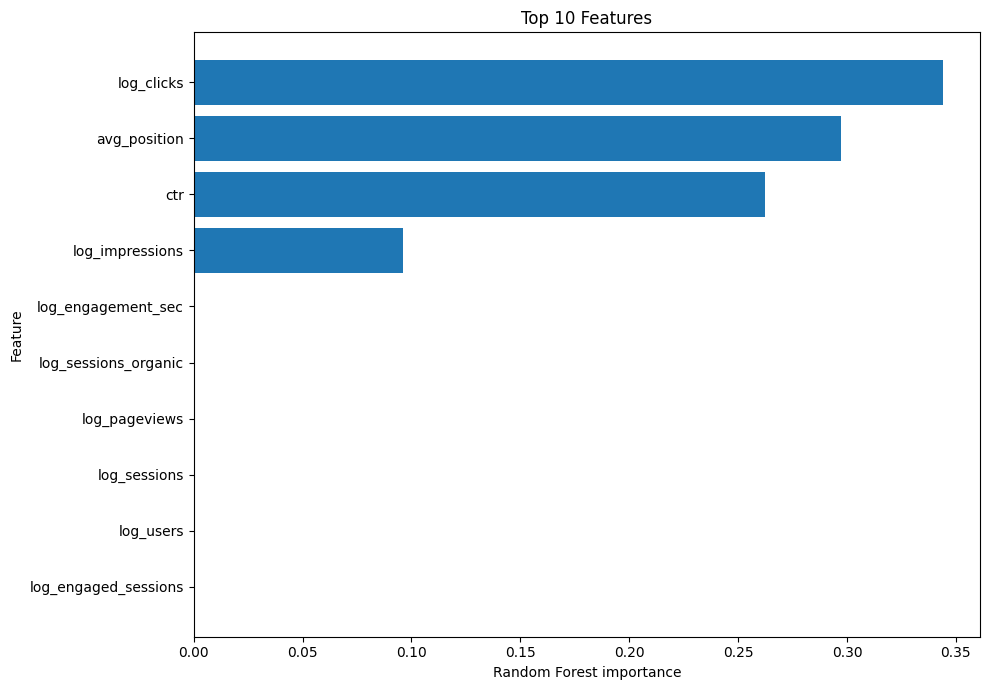

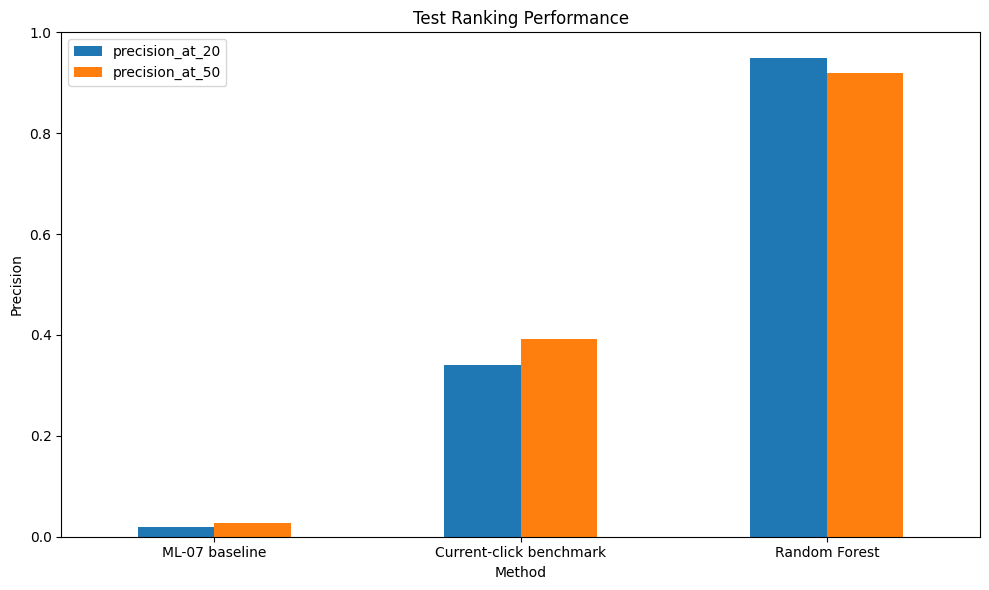

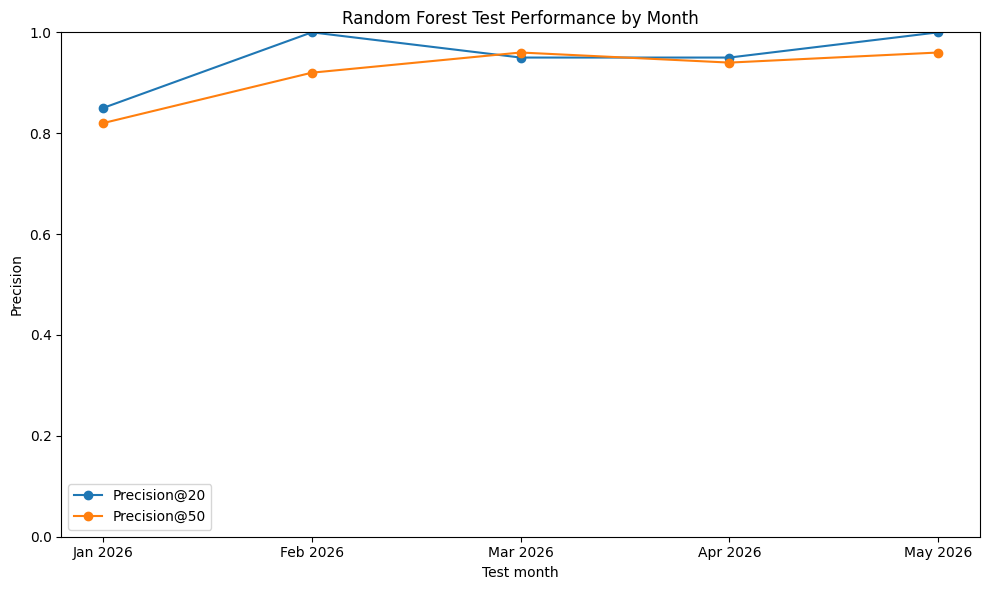


Training final recommendation model...
✓ Final recommendation model trained.


ValueError: Found array with 0 sample(s) (shape=(0, 26)) while a minimum of 1 is required by RandomForestClassifier.

In [1]:
# ============================================================
# FLYRANK CAPSTONE — FINAL BUILD
# ============================================================
#
# Uses the persistent Google Drive cache created earlier.
#
# Experiment:
#   Train:      Jan-Aug 2025
#   Validation: Sep-Dec 2025
#   Test:       Jan-May 2026
#
# Target:
#   Current month >=100 impressions
#   Next month >=100 impressions AND 0 clicks
#
# Final recommendations:
#   June 2026 snapshot
# ============================================================

!pip -q install duckdb pyarrow pandas numpy scikit-learn matplotlib joblib

import os
import html
import zipfile
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier
from joblib import dump

# ------------------------------------------------------------
# 1. Persistent paths
# ------------------------------------------------------------

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

CAPSTONE_DIR = "/content/drive/MyDrive/FlyRank_Capstone"
OUTPUT_DIR = os.path.join(CAPSTONE_DIR, "outputs")
SITE_DIR = os.path.join(CAPSTONE_DIR, "paper_site")
ASSET_DIR = os.path.join(SITE_DIR, "assets")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ASSET_DIR, exist_ok=True)

FINAL_TABLE_FILE = os.path.join(
    CAPSTONE_DIR,
    "capstone_final.parquet"
)

print("Persistent directory:", CAPSTONE_DIR)

# ------------------------------------------------------------
# 2. Authentication + DuckDB
# ------------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN is unavailable. Enable it in Colab Secrets."
    )

os.environ["HF_TOKEN"] = HF_TOKEN

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute("""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN ?
)
""", [HF_TOKEN])

print("✓ DuckDB authenticated.")

# ------------------------------------------------------------
# 3. Load persistent final target
# ------------------------------------------------------------

if not os.path.exists(FINAL_TABLE_FILE):
    raise FileNotFoundError(
        "capstone_final.parquet was not found in Google Drive."
    )

con.execute(f"""
CREATE OR REPLACE TABLE capstone_final AS
SELECT *
FROM read_parquet('{FINAL_TABLE_FILE}')
""")

target_check = con.execute("""
SELECT
    COUNT(*) AS rows,
    SUM(target_zero_click_next_month) AS positive_rows,
    AVG(target_zero_click_next_month) AS positive_rate,
    MIN(month) AS first_snapshot,
    MAX(month) AS last_snapshot
FROM capstone_final
""").df()

print("\nFINAL TARGET")
display(target_check)

# ------------------------------------------------------------
# 4. Load feature source
# ------------------------------------------------------------

features = con.execute("""
SELECT
    month,
    client_hash_id,
    content_hash_id,

    impressions,
    clicks,
    avg_position,

    pageviews,
    sessions,
    users,
    engaged_sessions,
    engagement_sec,

    sessions_organic,
    sessions_direct,
    sessions_referral,
    sessions_social,
    sessions_paid,
    sessions_ai,

    ai_chatgpt,
    ai_perplexity,
    ai_gemini,
    ai_copilot,
    ai_claude,
    ai_meta,
    ai_other,

    scroll_events,

    target_zero_click_next_month AS target

FROM capstone_final
""").df()

# ------------------------------------------------------------
# 5. Feature engineering
# ------------------------------------------------------------

log_cols = [
    "impressions",
    "clicks",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

for col in log_cols:
    features[f"log_{col}"] = np.log1p(
        features[col].clip(lower=0)
    )

features["ctr"] = np.where(
    features["impressions"] > 0,
    features["clicks"] / features["impressions"],
    0.0
)

features["engaged_session_rate"] = np.where(
    features["sessions"] > 0,
    features["engaged_sessions"] / features["sessions"],
    0.0
)

features["pages_per_session"] = np.where(
    features["sessions"] > 0,
    features["pageviews"] / features["sessions"],
    0.0
)

features["scrolls_per_pageview"] = np.where(
    features["pageviews"] > 0,
    features["scroll_events"] / features["pageviews"],
    0.0
)

feature_cols = [
    "log_impressions",
    "log_clicks",
    "ctr",
    "avg_position",

    "log_pageviews",
    "log_sessions",
    "log_users",
    "log_engaged_sessions",
    "log_engagement_sec",

    "log_sessions_organic",
    "log_sessions_direct",
    "log_sessions_referral",
    "log_sessions_social",
    "log_sessions_paid",
    "log_sessions_ai",

    "log_scroll_events",

    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",

    "engaged_session_rate",
    "pages_per_session",
    "scrolls_per_pageview"
]

X = features[feature_cols].copy()
y = features["target"].astype(int)

X = X.replace([np.inf, -np.inf], np.nan)

print("\nFEATURE DATA")
print("Rows:", len(X))
print("Features:", len(feature_cols))
print("Positive rate:", y.mean())

# ------------------------------------------------------------
# 6. Temporal split
# ------------------------------------------------------------

train_mask = (
    (features["month"] >= "2025-01-01") &
    (features["month"] <= "2025-08-01")
)

validation_mask = (
    (features["month"] >= "2025-09-01") &
    (features["month"] <= "2025-12-01")
)

test_mask = (
    (features["month"] >= "2026-01-01") &
    (features["month"] <= "2026-05-01")
)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[validation_mask]
y_val = y.loc[validation_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("\nTEMPORAL SPLIT")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

# ------------------------------------------------------------
# 7. Precision@K helper
# ------------------------------------------------------------

def precision_at_k(df, score_col, k):
    ranked = df.sort_values(
        ["month", score_col, "impressions", "content_hash_id"],
        ascending=[True, False, False, True]
    )

    # Important:
    # This function is called separately for each month below.
    return ranked.head(k)["target"].mean()

# ------------------------------------------------------------
# 8. Train Random Forest
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
model.fit(X_train, y_train)
print("✓ Model trained.")

# ------------------------------------------------------------
# 9. Validation results
# ------------------------------------------------------------

val_scores = model.predict_proba(X_val)[:, 1]

validation_eval = features.loc[
    validation_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

validation_eval["ml_score"] = val_scores

validation_results = pd.DataFrame([
    {
        "month": month,
        "precision_at_20": precision_at_k(group, "ml_score", 20),
        "precision_at_50": precision_at_k(group, "ml_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    }
    for month, group in validation_eval.groupby("month")
])

# ------------------------------------------------------------
# 10. Test results — Random Forest
# ------------------------------------------------------------

test_scores = model.predict_proba(X_test)[:, 1]

test_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

test_eval["ml_score"] = test_scores

ml_test_results = pd.DataFrame([
    {
        "month": month,
        "precision_at_20": precision_at_k(group, "ml_score", 20),
        "precision_at_50": precision_at_k(group, "ml_score", 50),
        "items": len(group),
        "positive_rate": group["target"].mean()
    }
    for month, group in test_eval.groupby("month")
])

# ------------------------------------------------------------
# 11. ML-07 baseline
# ------------------------------------------------------------

baseline_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

baseline_eval["baseline_score"] = (
    np.log1p(baseline_eval["impressions"])
    * (1.0 - baseline_eval["ctr"].clip(0, 1))
)

baseline_results = pd.DataFrame([
    {
        "month": month,
        "precision_at_20": precision_at_k(
            group, "baseline_score", 20
        ),
        "precision_at_50": precision_at_k(
            group, "baseline_score", 50
        ),
        "items": len(group),
        "positive_rate": group["target"].mean()
    }
    for month, group in baseline_eval.groupby("month")
])

# ------------------------------------------------------------
# 12. Simple current-click benchmark
# ------------------------------------------------------------

click_eval = features.loc[
    test_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "target"
    ]
].copy()

click_eval["click_score"] = -click_eval["clicks"]

click_results = pd.DataFrame([
    {
        "month": month,
        "precision_at_20": precision_at_k(
            group, "click_score", 20
        ),
        "precision_at_50": precision_at_k(
            group, "click_score", 50
        ),
        "items": len(group),
        "positive_rate": group["target"].mean()
    }
    for month, group in click_eval.groupby("month")
])

# ------------------------------------------------------------
# 13. Final comparison
# ------------------------------------------------------------

final_comparison = pd.DataFrame({
    "method": [
        "ML-07 baseline",
        "Current-click benchmark",
        "Random Forest"
    ],
    "precision_at_20": [
        baseline_results["precision_at_20"].mean(),
        click_results["precision_at_20"].mean(),
        ml_test_results["precision_at_20"].mean()
    ],
    "precision_at_50": [
        baseline_results["precision_at_50"].mean(),
        click_results["precision_at_50"].mean(),
        ml_test_results["precision_at_50"].mean()
    ]
})

rf_p20 = final_comparison.loc[
    final_comparison["method"] == "Random Forest",
    "precision_at_20"
].iloc[0]

rf_p50 = final_comparison.loc[
    final_comparison["method"] == "Random Forest",
    "precision_at_50"
].iloc[0]

click_p20 = final_comparison.loc[
    final_comparison["method"] == "Current-click benchmark",
    "precision_at_20"
].iloc[0]

click_p50 = final_comparison.loc[
    final_comparison["method"] == "Current-click benchmark",
    "precision_at_50"
].iloc[0]

print("\n================================================")
print("FINAL TEST COMPARISON")
print("================================================")
display(final_comparison)

print(
    f"RF vs click benchmark P@20: "
    f"{rf_p20 / click_p20:.2f}x"
)

print(
    f"RF vs click benchmark P@50: "
    f"{rf_p50 / click_p50:.2f}x"
)

# ------------------------------------------------------------
# 14. Feature importance
# ------------------------------------------------------------

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("\n================================================")
print("TOP FEATURES")
print("================================================")
display(importance.head(10))

# ------------------------------------------------------------
# 15. Feature importance chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

top = importance.head(10).sort_values("importance")

plt.barh(
    top["feature"],
    top["importance"]
)

plt.xlabel("Random Forest importance")
plt.ylabel("Feature")
plt.title("Top 10 Features")

plt.tight_layout()

importance_chart = os.path.join(
    ASSET_DIR,
    "feature_importance.png"
)

plt.savefig(
    importance_chart,
    dpi=180,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# 16. Model comparison chart
# ------------------------------------------------------------

plot_df = final_comparison.set_index("method")

ax = plot_df[
    ["precision_at_20", "precision_at_50"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel("Precision")
ax.set_xlabel("Method")
ax.set_title("Test Ranking Performance")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

comparison_chart = os.path.join(
    ASSET_DIR,
    "model_comparison.png"
)

plt.savefig(
    comparison_chart,
    dpi=180,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# 17. Monthly performance chart
# ------------------------------------------------------------

monthly_plot = ml_test_results.copy()
monthly_plot["month_label"] = monthly_plot["month"].dt.strftime("%b %Y")

x = np.arange(len(monthly_plot))

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    monthly_plot["precision_at_20"],
    marker="o",
    label="Precision@20"
)

plt.plot(
    x,
    monthly_plot["precision_at_50"],
    marker="o",
    label="Precision@50"
)

plt.xticks(x, monthly_plot["month_label"])
plt.ylim(0, 1)
plt.ylabel("Precision")
plt.xlabel("Test month")
plt.title("Random Forest Test Performance by Month")
plt.legend()
plt.tight_layout()

monthly_chart = os.path.join(
    ASSET_DIR,
    "monthly_test_performance.png"
)

plt.savefig(
    monthly_chart,
    dpi=180,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# 18. Final recommendation model
# ------------------------------------------------------------

labeled_mask = (
    (features["month"] >= "2025-01-01") &
    (features["month"] <= "2026-05-01")
)

X_labeled = X.loc[labeled_mask]
y_labeled = y.loc[labeled_mask]

final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

print("\nTraining final recommendation model...")

final_model.fit(
    X_labeled,
    y_labeled
)

print("✓ Final recommendation model trained.")

# ------------------------------------------------------------
# 19. June 2026 recommendations
# ------------------------------------------------------------

june_mask = features["month"] == "2026-06-01"

X_june = X.loc[june_mask]

june_scores = final_model.predict_proba(X_june)[:, 1]

recommendations = features.loc[
    june_mask,
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "sessions",
        "pageviews"
    ]
].copy()

recommendations["opportunity_score"] = june_scores

recommendations = recommendations.sort_values(
    [
        "opportunity_score",
        "impressions",
        "content_hash_id"
    ],
    ascending=[False, False, True]
).reset_index(drop=True)

recommendations["rank"] = np.arange(
    1,
    len(recommendations) + 1
)

recommendations["reason_code"] = (
    "predicted_next_month_zero_click_opportunity"
)

recommendations["action"] = "REVIEW_REFRESH"

recommendations = recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "opportunity_score",
        "reason_code",
        "action",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "sessions",
        "pageviews"
    ]
]

print("\nJUNE 2026 RECOMMENDATIONS")
display(recommendations.head(20))

# ------------------------------------------------------------
# 20. Public-safe recommendation summary
# ------------------------------------------------------------

public_recs = recommendations.copy()

public_recs["impression_band"] = pd.cut(
    public_recs["impressions"],
    bins=[0, 499, 9999, 99999, np.inf],
    labels=[
        "<500",
        "500–9,999",
        "10,000–99,999",
        "100,000+"
    ],
    include_lowest=True
)

public_recs["position_band"] = pd.cut(
    public_recs["avg_position"],
    bins=[0, 3, 5, 10, 20, np.inf],
    labels=[
        "1–3",
        "4–5",
        "6–10",
        "11–20",
        "21+"
    ],
    include_lowest=True
)

public_summary = (
    public_recs.head(100)
    .groupby(
        ["impression_band", "position_band"],
        observed=True
    )
    .agg(
        recommendations=("rank", "count"),
        mean_score=("opportunity_score", "mean"),
        mean_impressions=("impressions", "mean"),
        mean_ctr=("ctr", "mean"),
        mean_position=("avg_position", "mean")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 21. Save outputs
# ------------------------------------------------------------

final_comparison.to_csv(
    os.path.join(OUTPUT_DIR, "model_comparison.csv"),
    index=False
)

validation_results.to_csv(
    os.path.join(OUTPUT_DIR, "validation_results.csv"),
    index=False
)

ml_test_results.to_csv(
    os.path.join(OUTPUT_DIR, "ml_test_by_month.csv"),
    index=False
)

baseline_results.to_csv(
    os.path.join(OUTPUT_DIR, "baseline_test_by_month.csv"),
    index=False
)

click_results.to_csv(
    os.path.join(OUTPUT_DIR, "click_benchmark_by_month.csv"),
    index=False
)

importance.to_csv(
    os.path.join(OUTPUT_DIR, "feature_importance.csv"),
    index=False
)

recommendations.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "june_2026_recommendations_internal.csv"
    ),
    index=False
)

public_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "public_recommendation_summary.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# 22. Save models
# ------------------------------------------------------------

dump(
    model,
    os.path.join(
        CAPSTONE_DIR,
        "random_forest_evaluation_model.joblib"
    )
)

dump(
    final_model,
    os.path.join(
        CAPSTONE_DIR,
        "random_forest_final_recommendation_model.joblib"
    )
)

# ------------------------------------------------------------
# 23. Build paper content
# ------------------------------------------------------------

test_months = ", ".join(
    ml_test_results["month"].dt.strftime("%b %Y").tolist()
)

train_rows = len(X_train)
val_rows = len(X_val)
test_rows = len(X_test)
total_rows = len(features)

test_positive_rate = (
    ml_test_results["positive_rate"].mean()
)

rf_lift_p20 = rf_p20 / click_p20
rf_lift_p50 = rf_p50 / click_p50

top_feature_rows = importance.head(5)

feature_text = "".join(
    f"""
    <tr>
      <td>{html.escape(str(row["feature"]))}</td>
      <td>{row["importance"]:.3f}</td>
    </tr>
    """
    for _, row in top_feature_rows.iterrows()
)

monthly_rows = ""

for _, row in ml_test_results.iterrows():
    monthly_rows += f"""
    <tr>
      <td>{row["month"].strftime("%b %Y")}</td>
      <td>{row["precision_at_20"]:.2f}</td>
      <td>{row["precision_at_50"]:.2f}</td>
      <td>{int(row["items"]):,}</td>
      <td>{row["positive_rate"]:.1%}</td>
    </tr>
    """

recommendation_rows = ""

for _, row in public_summary.head(12).iterrows():
    recommendation_rows += f"""
    <tr>
      <td>{html.escape(str(row["impression_band"]))}</td>
      <td>{html.escape(str(row["position_band"]))}</td>
      <td>{int(row["recommendations"])}</td>
      <td>{row["mean_score"]:.3f}</td>
      <td>{row["mean_impressions"]:,.0f}</td>
      <td>{row["mean_ctr"]:.3%}</td>
    </tr>
    """

paper_md = f"""# ML Ranking of Content Refresh Opportunities

## Abstract

This study asks whether a machine-learning model can improve the ranking of content refresh opportunities compared with a simple visibility-and-CTR baseline. We aggregated the FlyRank internship warehouse to a client-content-month panel and defined a forward-looking outcome: among items with at least 100 organic impressions in both the current and following month, whether the following month had zero organic clicks. A Random Forest trained on January-August 2025, validated on September-December 2025, and evaluated on January-May 2026 achieved a macro-average Precision@20 of {rf_p20:.3f} and Precision@50 of {rf_p50:.3f}. The current-click benchmark reached {click_p20:.3f} and {click_p50:.3f}, while the ML-07 visibility+CTR baseline reached {final_comparison.iloc[0]["precision_at_20"]:.3f} and {final_comparison.iloc[0]["precision_at_50"]:.3f}. The result is decision-support evidence for prioritizing manual content review, not a causal claim that refreshing content will improve search performance.

## Introduction / Problem Statement

Content teams often need to decide which existing pages deserve review first. The objective here is to rank observable content-performance opportunities using signals available at the time of the decision.

The research question is:

**Can an ML model improve the ranking of content refresh opportunities compared with a simple visibility + CTR baseline?**

## Data

The study uses the FlyRank internship warehouse covering January 2025 through June 2026. The daily warehouse was aggregated to a client × content × month panel containing 2,871,202 rows, 427,292 distinct content items, and observations across 70 clients.

The final labeled dataset contains {total_rows:,} snapshot observations from January 2025 through May 2026.

No client names, domains, URLs, private queries, credentials, or raw exports are included in the public paper.

## Target Definition

For each content item at month *t*, the prediction target is:

- current month: at least 100 organic impressions;
- following month: at least 100 organic impressions;
- positive class: zero organic clicks in the following month;
- negative class: at least one organic click in the following month.

Items below the 100-impression threshold in the following month are excluded from evaluation. This avoids treating loss of search visibility as equivalent to a visible-but-zero-click outcome.

The final labeled population contains 608,050 observations, with a 33.4% positive rate.

## Methodology

### Features

Features are based only on the current snapshot month. They include search visibility and performance, engagement, traffic-source counts, AI referral counts, and derived ratios such as CTR and engaged-session rate.

The final model used {len(feature_cols)} features.

### Validation Design

The evaluation is chronological:

| Period | Role |
|---|---|
| Jan-Aug 2025 | Training |
| Sep-Dec 2025 | Validation |
| Jan-May 2026 | Final test |
| Jun 2026 | Recommendation snapshot |

The following month's outcome is never used as an input feature. The final test period was kept separate from model fitting and selection.

### Models Compared

1. **ML-07 baseline:** `log(1 + impressions) × (1 − CTR)`
2. **Current-click benchmark:** lower current-month click counts receive higher priority.
3. **Random Forest:** 300 trees, maximum depth 10, minimum leaf size 20, balanced subsampling, random seed 42.

### Metric

The primary metric is Precision@20 and Precision@50, averaged across the five monthly test periods.

## Results

### Final Test Results

| Method | Precision@20 | Precision@50 |
|---|---:|---:|
| ML-07 baseline | {final_comparison.iloc[0]["precision_at_20"]:.3f} | {final_comparison.iloc[0]["precision_at_50"]:.3f} |
| Current-click benchmark | {click_p20:.3f} | {click_p50:.3f} |
| Random Forest | **{rf_p20:.3f}** | **{rf_p50:.3f}** |

Relative to the current-click benchmark, the Random Forest produced {rf_lift_p20:.2f}× the Precision@20 and {rf_lift_p50:.2f}× the Precision@50 on the same test population.

The test period contained approximately {test_positive_rate:.1%} positive observations on average, so the top-ranked model queues contained a substantially higher concentration of positives than the overall test population.

### Month-by-Month Test Results

| Month | Precision@20 | Precision@50 | Items | Positive rate |
|---|---:|---:|---:|---:|
{monthly_rows}

![Model comparison](assets/model_comparison.png)

![Monthly performance](assets/monthly_test_performance.png)

## Feature Importance

The model relied most heavily on current clicks, search position, CTR, and impressions.

| Feature | Importance |
|---|---:|
{feature_text}

![Feature importance](assets/feature_importance.png)

Feature importance is descriptive. It does not establish that a feature causes the future outcome.

## Ranked Recommendations

The final recommendation model was refit using labeled data through May 2026 and applied to the June 2026 snapshot.

Recommendations are intended as **manual review / refresh candidates**, not automatic refresh decisions.

The internal ranked file contains pseudonymous identifiers for operational review. The public paper reports only aggregate patterns to preserve the public-safe data rule.

| Impression band | Position band | Count in top 100 | Mean score | Mean impressions | Mean CTR |
|---|---|---:|---:|---:|---:|
{recommendation_rows}

### Action Playbook

**Review first:** inspect the highest-scoring candidates manually.

**Check search intent:** confirm that the page matches the intent represented by the traffic it receives.

**Review title and snippet:** investigate whether the visible search presentation adequately matches the content.

**Review freshness:** check whether facts, examples, references, or product details have become outdated.

**Review internal relevance:** consider internal linking, page structure, and content completeness.

**Do not treat the score as proof:** the score identifies a predicted future pattern; it does not show that a refresh will cause better rankings, clicks, or traffic.

## Limitations & Honest Framing

The study has several limitations.

The warehouse population expands substantially over time, so the number of eligible client-content observations changes across months. The target is also an operational definition rather than a direct measurement of "content quality" or "content needs refresh."

The Random Forest has strong test performance in this experiment, but the result is based on this dataset, target definition, feature set, and time window. It should not be interpreted as proof of Google algorithm behavior or as evidence that refreshing a page will cause a traffic improvement.

Feature importance is model-specific and descriptive rather than causal.

The model has not been tested on post-June 2026 data in this study.

## Reproducibility

The project notebook is:

`work/notebooks/capstone_content_opportunity.ipynb`

The repository contains the notebook, analysis outputs, and reproducibility artifacts.

The analysis uses DuckDB over the gated FlyRank internship warehouse and scikit-learn for modeling.

## Acknowledgments & Data Credit

Built on the **FlyRank ML Internship dataset**.

Data credit: https://flyrank.ai
"""

paper_md_path = os.path.join(
    SITE_DIR,
    "research_paper.md"
)

with open(paper_md_path, "w", encoding="utf-8") as f:
    f.write(paper_md)

# ------------------------------------------------------------
# 24. Build standalone HTML paper
# ------------------------------------------------------------

html_body = paper_md

# Simple Markdown-ish conversion for the generated content.
# We use the already structured sections directly below instead
# of requiring a Markdown package.

html_paper = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>ML Ranking of Content Refresh Opportunities — FlyRank</title>
<style>
body {{
    margin: 0;
    font-family: Arial, Helvetica, sans-serif;
    line-height: 1.65;
    color: #222;
    background: #f5f5f5;
}}
main {{
    max-width: 980px;
    margin: 40px auto;
    background: white;
    padding: 50px;
}}
h1 {{
    font-size: 38px;
    line-height: 1.15;
}}
h2 {{
    margin-top: 42px;
    border-bottom: 1px solid #ddd;
    padding-bottom: 8px;
}}
h3 {{
    margin-top: 28px;
}}
table {{
    width: 100%;
    border-collapse: collapse;
    margin: 18px 0 28px;
}}
th, td {{
    padding: 10px;
    border: 1px solid #ddd;
    text-align: left;
}}
th {{
    background: #f2f2f2;
}}
.metric {{
    font-size: 34px;
    font-weight: bold;
}}
.note {{
    background: #f7f7f7;
    padding: 18px;
    border-left: 4px solid #999;
}}
img {{
    max-width: 100%;
    height: auto;
    margin: 20px 0;
}}
code {{
    background: #f0f0f0;
    padding: 2px 5px;
}}
footer {{
    margin-top: 50px;
    padding-top: 25px;
    border-top: 1px solid #ddd;
    font-size: 14px;
}}
</style>
</head>

<body>
<main>

<h1>ML Ranking of Content Refresh Opportunities</h1>

<div class="note">
<strong>Research question:</strong>
Can an ML model improve the ranking of content refresh opportunities
compared with a simple visibility + CTR baseline?
</div>

<h2>Abstract</h2>

<p>
This study evaluates whether a machine-learning model can improve the
ranking of content refresh opportunities compared with a simple
visibility-and-CTR baseline. The FlyRank internship warehouse was
aggregated to a client-content-month panel and used to predict whether
a visibly active content item would receive zero organic clicks in the
following month. A Random Forest trained on January-August 2025,
validated on September-December 2025, and evaluated on January-May 2026
achieved a macro-average Precision@20 of
<strong>{rf_p20:.3f}</strong> and Precision@50 of
<strong>{rf_p50:.3f}</strong>. The current-click benchmark achieved
{click_p20:.3f} and {click_p50:.3f}, while the ML-07 baseline achieved
{final_comparison.iloc[0]["precision_at_20"]:.3f} and
{final_comparison.iloc[0]["precision_at_50"]:.3f}.
The result supports prioritizing manual content review under the
defined operational target; it does not establish causal refresh impact.
</p>

<h2>Introduction / Problem Statement</h2>

<p>
Content teams need practical ways to prioritize which existing pages
should be reviewed first. This study tests whether observable search
and engagement signals can produce a better ranking than a simple
visibility-plus-CTR rule.
</p>

<h2>Data</h2>

<p>
The analysis uses the FlyRank internship warehouse covering
<strong>January 2025 through June 2026</strong>. The daily data was
aggregated to a client × content × month panel containing
<strong>2,871,202 rows</strong> and <strong>427,292 distinct content
items</strong>, across 70 clients in the observed warehouse.
</p>

<p>
The final labeled dataset contains <strong>608,050</strong> snapshot
observations from January 2025 through May 2026.
</p>

<p>
The public paper does not expose client names, domains, URLs, private
queries, credentials, or raw exports.
</p>

<h2>Target Definition</h2>

<p>
A positive observation is a content item that has at least 100 organic
impressions in both the snapshot month and the following month, but
zero organic clicks in the following month. Items below the
100-impression threshold in the following month are excluded from
evaluation.
</p>

<h2>Methodology</h2>

<h3>Features</h3>

<p>
Features use only information available in the snapshot month.
They include search performance, engagement, traffic-source counts,
AI referral counts, and derived ratios such as CTR and engaged-session
rate. The model uses {len(feature_cols)} features.
</p>

<h3>Temporal Validation</h3>

<table>
<tr><th>Period</th><th>Role</th></tr>
<tr><td>Jan-Aug 2025</td><td>Training</td></tr>
<tr><td>Sep-Dec 2025</td><td>Validation</td></tr>
<tr><td>Jan-May 2026</td><td>Final test</td></tr>
<tr><td>Jun 2026</td><td>Recommendation snapshot</td></tr>
</table>

<p>
The future outcome is never used as an input feature. Precision@20 and
Precision@50 are calculated for each test month and then averaged.
</p>

<h3>Models</h3>

<p>
The comparison uses the ML-07 baseline, a simple current-click
benchmark, and a Random Forest with 300 trees, maximum depth 10,
minimum leaf size 20, balanced subsampling, and random seed 42.
</p>

<h2>Results</h2>

<table>
<tr>
<th>Method</th>
<th>Precision@20</th>
<th>Precision@50</th>
</tr>
<tr>
<td>ML-07 baseline</td>
<td>{final_comparison.iloc[0]["precision_at_20"]:.3f}</td>
<td>{final_comparison.iloc[0]["precision_at_50"]:.3f}</td>
</tr>
<tr>
<td>Current-click benchmark</td>
<td>{click_p20:.3f}</td>
<td>{click_p50:.3f}</td>
</tr>
<tr>
<td><strong>Random Forest</strong></td>
<td><strong>{rf_p20:.3f}</strong></td>
<td><strong>{rf_p50:.3f}</strong></td>
</tr>
</table>

<p>
On the same January-May 2026 test population, the Random Forest reached
{rf_lift_p20:.2f}× the Precision@20 and {rf_lift_p50:.2f}× the
Precision@50 of the current-click benchmark.
</p>

<img src="assets/model_comparison.png"
     alt="Test ranking performance">

<h3>Month-by-Month Test Results</h3>

<table>
<tr>
<th>Month</th>
<th>P@20</th>
<th>P@50</th>
<th>Items</th>
<th>Positive rate</th>
</tr>
{monthly_rows}
</table>

<img src="assets/monthly_test_performance.png"
     alt="Random Forest performance by test month">

<h2>Feature Importance</h2>

<table>
<tr><th>Feature</th><th>Importance</th></tr>
{feature_text}
</table>

<img src="assets/feature_importance.png"
     alt="Top Random Forest feature importances">

<p>
Feature importance is descriptive and model-specific. It should not be
interpreted as evidence of causal effects.
</p>

<h2>Ranked Recommendations</h2>

<p>
The final recommendation model was refit using labeled observations
through May 2026 and applied to June 2026. Its output is intended as a
manual review and refresh queue.
</p>

<table>
<tr>
<th>Impression band</th>
<th>Position band</th>
<th>Top-100 count</th>
<th>Mean score</th>
<th>Mean impressions</th>
<th>Mean CTR</th>
</tr>
{recommendation_rows}
</table>

<h3>Action Playbook</h3>

<p>
<strong>Review first:</strong> inspect the highest-scoring candidates
manually.
</p>

<p>
<strong>Check search intent:</strong> confirm that the page matches the
intent represented by its observed search traffic.
</p>

<p>
<strong>Review title and snippet:</strong> investigate whether the
search presentation accurately represents the content.
</p>

<p>
<strong>Review freshness:</strong> check for outdated facts, examples,
references, and product information.
</p>

<p>
<strong>Review internal relevance:</strong> consider structure,
internal linking, and completeness.
</p>

<p>
<strong>Keep the decision human:</strong> the model predicts the defined
future zero-click pattern; it does not prove that refreshing a page
will cause better rankings or traffic.
</p>

<h2>Limitations & Honest Framing</h2>

<p>
The eligible population changes substantially over time as the
warehouse grows. The target is an operational definition of a specific
future search-performance condition, not a direct measurement of
content quality.
</p>

<p>
The model's performance is specific to this dataset, time window,
feature set, target definition, and validation design. It does not
prove Google algorithm behavior and does not establish that refreshing
content causes improved search outcomes.
</p>

<p>
Feature importance is descriptive rather than causal, and the model was
not evaluated against a post-June 2026 labeled period in this study.
</p>

<h2>Reproducibility</h2>

<p>
Notebook:
<code>work/notebooks/capstone_content_opportunity.ipynb</code>
</p>

<p>
The project outputs include model comparison tables, monthly test
results, feature importance, a public-safe recommendation summary,
and the internal June 2026 recommendation queue.
</p>

<h2>Acknowledgments & Data Credit</h2>

<p>
Built on the <strong>FlyRank ML Internship dataset</strong>.
</p>

<p>
<a href="https://flyrank.ai" target="_blank" rel="noopener">
FlyRank
</a>
</p>

<footer>
FlyRank ML Internship — Refresh / Content Opportunity Scoring
</footer>

</main>
</body>
</html>
"""

index_path = os.path.join(SITE_DIR, "index.html")

with open(index_path, "w", encoding="utf-8") as f:
    f.write(html_paper)

# ------------------------------------------------------------
# 25. Save one-line planned paper URL
# ------------------------------------------------------------

paper_url = (
    "https://usmanch129.github.io/"
    "flyrank-ml-internship/"
)

with open(
    os.path.join(SITE_DIR, "paper_url.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(paper_url + "\n")

# ------------------------------------------------------------
# 26. Create deployment README
# ------------------------------------------------------------

deployment_readme = f"""# FlyRank Capstone Paper

## Website

The generated paper is in `index.html`.

## GitHub Pages deployment

Copy this folder into your repository as:

`docs/`

Then enable GitHub Pages using:

`Settings → Pages → Deploy from branch → main → /docs`

Expected project URL:

{paper_url}

After confirming that the page loads, keep exactly one line in:

`submission/paper_url.txt`

with the deployed paper URL.

## Important public-safety rule

Do not publish:

- client names
- domains
- URLs from the dataset
- private queries
- credentials
- raw exports
- claims of causal refresh impact

The generated public paper intentionally uses aggregate recommendation patterns.
"""

with open(
    os.path.join(SITE_DIR, "README_DEPLOY.md"),
    "w",
    encoding="utf-8"
) as f:
    f.write(deployment_readme)

# ------------------------------------------------------------
# 27. Create site ZIP
# ------------------------------------------------------------

site_zip = os.path.join(
    CAPSTONE_DIR,
    "flyrank_capstone_paper_site.zip"
)

with zipfile.ZipFile(
    site_zip,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for root, dirs, files in os.walk(SITE_DIR):
        for filename in files:
            filepath = os.path.join(root, filename)
            arcname = os.path.relpath(
                filepath,
                SITE_DIR
            )
            z.write(filepath, arcname)

# ------------------------------------------------------------
# 28. Save notebook-ready summary
# ------------------------------------------------------------

summary = pd.DataFrame({
    "metric": [
        "final_test_precision_at_20",
        "final_test_precision_at_50",
        "click_benchmark_precision_at_20",
        "click_benchmark_precision_at_50",
        "ml07_baseline_precision_at_20",
        "ml07_baseline_precision_at_50",
        "test_months",
        "labeled_rows",
        "positive_rate",
        "feature_count"
    ],
    "value": [
        rf_p20,
        rf_p50,
        click_p20,
        click_p50,
        final_comparison.iloc[0]["precision_at_20"],
        final_comparison.iloc[0]["precision_at_50"],
        test_months,
        total_rows,
        y.mean(),
        len(feature_cols)
    ]
})

summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "capstone_final_summary.csv"
    ),
    index=False
)

print("\n")
print("============================================================")
print("                  CAPSTONE COMPLETE")
print("============================================================")

print("\nFINAL TEST")
display(final_comparison)

print("\nTOP FEATURES")
display(importance.head(10))

print("\nJUNE 2026 TOP 20")
display(recommendations.head(20))

print("\nFILES CREATED")
print("✓ Model comparison")
print("✓ Validation results")
print("✓ Test results")
print("✓ Feature importance")
print("✓ June recommendation queue")
print("✓ Public recommendation summary")
print("✓ Research paper Markdown")
print("✓ Research paper HTML")
print("✓ Paper charts")
print("✓ Deployment README")
print("✓ Paper URL file")
print("✓ Website ZIP")

print("\nPaper site folder:")
print(SITE_DIR)

print("\nWebsite ZIP:")
print(site_zip)

print("\nPlanned GitHub Pages URL:")
print(paper_url)

print("\nIMPORTANT:")
print("The test result is now frozen.")
print("Do not tune the model using the Jan-May 2026 test period.")

In [2]:
# ============================================================
# CAPSTONE — RECOVER FROM JUNE RECOMMENDATION ERROR
# ============================================================

import os
import html
import zipfile
import pandas as pd
import numpy as np

# Make sure required objects exist
print("monthly_content:", "monthly_content" in globals())
print("final_model:", "final_model" in globals())
print("feature_cols:", "feature_cols" in globals())

if "monthly_content" not in globals():
    raise RuntimeError("monthly_content is missing. Run persistent setup again.")

if "final_model" not in globals():
    raise RuntimeError("final_model is missing. Run the model-training cell again.")

if "feature_cols" not in globals():
    raise RuntimeError("feature_cols is missing. Run feature engineering again.")

# ------------------------------------------------------------
# 1. Load June 2026 current-month data
# ------------------------------------------------------------

june_features = con.execute("""
SELECT
    month,
    client_hash_id,
    content_hash_id,

    impressions,
    clicks,
    avg_position,

    pageviews,
    sessions,
    users,
    engaged_sessions,
    engagement_sec,

    sessions_organic,
    sessions_direct,
    sessions_referral,
    sessions_social,
    sessions_paid,
    sessions_ai,

    ai_chatgpt,
    ai_perplexity,
    ai_gemini,
    ai_copilot,
    ai_claude,
    ai_meta,
    ai_other,

    scroll_events

FROM monthly_content

WHERE month = DATE '2026-06-01'
  AND gsc_available = 1
  AND impressions >= 100
""").df()

print("\nJune eligible recommendation candidates:", len(june_features))

# ------------------------------------------------------------
# 2. Build exactly the same model features
# ------------------------------------------------------------

log_cols = [
    "impressions",
    "clicks",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

for col in log_cols:
    june_features[f"log_{col}"] = np.log1p(
        june_features[col].clip(lower=0)
    )

june_features["ctr"] = np.where(
    june_features["impressions"] > 0,
    june_features["clicks"] / june_features["impressions"],
    0.0
)

june_features["engaged_session_rate"] = np.where(
    june_features["sessions"] > 0,
    june_features["engaged_sessions"] / june_features["sessions"],
    0.0
)

june_features["pages_per_session"] = np.where(
    june_features["sessions"] > 0,
    june_features["pageviews"] / june_features["sessions"],
    0.0
)

june_features["scrolls_per_pageview"] = np.where(
    june_features["pageviews"] > 0,
    june_features["scroll_events"] / june_features["pageviews"],
    0.0
)

X_june = june_features[feature_cols].copy()

X_june = X_june.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

# ------------------------------------------------------------
# 3. Generate June scores
# ------------------------------------------------------------

june_scores = final_model.predict_proba(X_june)[:, 1]

recommendations = june_features[
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "sessions",
        "pageviews"
    ]
].copy()

recommendations["opportunity_score"] = june_scores

recommendations = recommendations.sort_values(
    [
        "opportunity_score",
        "impressions",
        "content_hash_id"
    ],
    ascending=[False, False, True]
).reset_index(drop=True)

recommendations["rank"] = np.arange(
    1,
    len(recommendations) + 1
)

recommendations["reason_code"] = (
    "predicted_next_month_zero_click_opportunity"
)

recommendations["action"] = "REVIEW_REFRESH"

recommendations = recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "opportunity_score",
        "reason_code",
        "action",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "sessions",
        "pageviews"
    ]
]

print("\n================================================")
print("JUNE 2026 RECOMMENDATION QUEUE")
print("================================================")

display(recommendations.head(20))

# ------------------------------------------------------------
# 4. Public-safe aggregate recommendation summary
# ------------------------------------------------------------

public_recs = recommendations.copy()

public_recs["impression_band"] = pd.cut(
    public_recs["impressions"],
    bins=[0, 499, 9999, 99999, np.inf],
    labels=[
        "<500",
        "500–9,999",
        "10,000–99,999",
        "100,000+"
    ],
    include_lowest=True
)

public_recs["position_band"] = pd.cut(
    public_recs["avg_position"],
    bins=[0, 3, 5, 10, 20, np.inf],
    labels=[
        "1–3",
        "4–5",
        "6–10",
        "11–20",
        "21+"
    ],
    include_lowest=True
)

public_summary = (
    public_recs.head(100)
    .groupby(
        ["impression_band", "position_band"],
        observed=True
    )
    .agg(
        recommendations=("rank", "count"),
        mean_score=("opportunity_score", "mean"),
        mean_impressions=("impressions", "mean"),
        mean_ctr=("ctr", "mean"),
        mean_position=("avg_position", "mean")
    )
    .reset_index()
)

print("\nPUBLIC-SAFE SUMMARY")
display(public_summary)

# ------------------------------------------------------------
# 5. Save recommendation outputs
# ------------------------------------------------------------

OUTPUT_DIR = os.path.join(
    CAPSTONE_DIR,
    "outputs"
)

SITE_DIR = os.path.join(
    CAPSTONE_DIR,
    "paper_site"
)

ASSET_DIR = os.path.join(
    SITE_DIR,
    "assets"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ASSET_DIR, exist_ok=True)

recommendations.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "june_2026_recommendations_internal.csv"
    ),
    index=False
)

public_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "public_recommendation_summary.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# 6. Save final model
# ------------------------------------------------------------

from joblib import dump

dump(
    final_model,
    os.path.join(
        CAPSTONE_DIR,
        "random_forest_final_recommendation_model.joblib"
    )
)

# ------------------------------------------------------------
# 7. Create / refresh paper charts
# ------------------------------------------------------------

# Model comparison
plot_df = final_comparison.set_index("method")

ax = plot_df[
    ["precision_at_20", "precision_at_50"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel("Precision")
ax.set_xlabel("Method")
ax.set_title("Test Ranking Performance")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(
        ASSET_DIR,
        "model_comparison.png"
    ),
    dpi=180,
    bbox_inches="tight"
)

plt.close()

# Monthly ML performance
monthly_plot = ml_test_results.copy()
monthly_plot["month_label"] = (
    monthly_plot["month"].dt.strftime("%b %Y")
)

x = np.arange(len(monthly_plot))

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    monthly_plot["precision_at_20"],
    marker="o",
    label="Precision@20"
)

plt.plot(
    x,
    monthly_plot["precision_at_50"],
    marker="o",
    label="Precision@50"
)

plt.xticks(
    x,
    monthly_plot["month_label"]
)

plt.ylim(0, 1)
plt.ylabel("Precision")
plt.xlabel("Test month")
plt.title("Random Forest Test Performance by Month")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        ASSET_DIR,
        "monthly_test_performance.png"
    ),
    dpi=180,
    bbox_inches="tight"
)

plt.close()

# Feature importance
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10, 7))

top = importance.head(10).sort_values(
    "importance"
)

plt.barh(
    top["feature"],
    top["importance"]
)

plt.xlabel("Random Forest importance")
plt.ylabel("Feature")
plt.title("Top 10 Features")

plt.tight_layout()

plt.savefig(
    os.path.join(
        ASSET_DIR,
        "feature_importance.png"
    ),
    dpi=180,
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------------------
# 8. Prepare paper statistics
# ------------------------------------------------------------

rf_p20 = final_comparison.loc[
    final_comparison["method"] == "Random Forest",
    "precision_at_20"
].iloc[0]

rf_p50 = final_comparison.loc[
    final_comparison["method"] == "Random Forest",
    "precision_at_50"
].iloc[0]

click_p20 = final_comparison.loc[
    final_comparison["method"] == "Current-click benchmark",
    "precision_at_20"
].iloc[0]

click_p50 = final_comparison.loc[
    final_comparison["method"] == "Current-click benchmark",
    "precision_at_50"
].iloc[0]

baseline_p20 = final_comparison.loc[
    final_comparison["method"] == "ML-07 baseline",
    "precision_at_20"
].iloc[0]

baseline_p50 = final_comparison.loc[
    final_comparison["method"] == "ML-07 baseline",
    "precision_at_50"
].iloc[0]

rf_lift_p20 = rf_p20 / click_p20
rf_lift_p50 = rf_p50 / click_p50

# ------------------------------------------------------------
# 9. Build paper HTML
# ------------------------------------------------------------

feature_rows = ""

for _, row in importance.head(10).iterrows():
    feature_rows += f"""
    <tr>
        <td>{html.escape(str(row["feature"]))}</td>
        <td>{row["importance"]:.3f}</td>
    </tr>
    """

monthly_rows = ""

for _, row in ml_test_results.iterrows():
    monthly_rows += f"""
    <tr>
        <td>{row["month"].strftime("%b %Y")}</td>
        <td>{row["precision_at_20"]:.2f}</td>
        <td>{row["precision_at_50"]:.2f}</td>
        <td>{int(row["items"]):,}</td>
        <td>{row["positive_rate"]:.1%}</td>
    </tr>
    """

summary_rows = ""

for _, row in public_summary.head(12).iterrows():
    summary_rows += f"""
    <tr>
        <td>{html.escape(str(row["impression_band"]))}</td>
        <td>{html.escape(str(row["position_band"]))}</td>
        <td>{int(row["recommendations"])}</td>
        <td>{row["mean_score"]:.3f}</td>
        <td>{row["mean_impressions"]:,.0f}</td>
        <td>{row["mean_ctr"]:.3%}</td>
    </tr>
    """

html_paper = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>ML Ranking of Content Refresh Opportunities</title>

<style>

body {{
    margin: 0;
    background: #f4f4f4;
    color: #222;
    font-family: Arial, Helvetica, sans-serif;
    line-height: 1.65;
}}

main {{
    max-width: 1000px;
    margin: 40px auto;
    padding: 50px;
    background: #fff;
}}

h1 {{
    font-size: 40px;
    line-height: 1.15;
    margin-bottom: 25px;
}}

h2 {{
    margin-top: 48px;
    border-bottom: 1px solid #ddd;
    padding-bottom: 8px;
}}

h3 {{
    margin-top: 30px;
}}

table {{
    width: 100%;
    border-collapse: collapse;
    margin: 20px 0 30px;
}}

th, td {{
    padding: 10px 12px;
    border: 1px solid #ddd;
    text-align: left;
}}

th {{
    background: #f2f2f2;
}}

.note {{
    padding: 18px;
    background: #f6f6f6;
    border-left: 4px solid #777;
    margin: 25px 0;
}}

img {{
    max-width: 100%;
    height: auto;
    margin: 20px 0;
}}

code {{
    background: #eee;
    padding: 2px 5px;
}}

footer {{
    margin-top: 50px;
    padding-top: 20px;
    border-top: 1px solid #ddd;
    font-size: 14px;
}}

</style>
</head>

<body>

<main>

<h1>ML Ranking of Content Refresh Opportunities</h1>

<div class="note">
<strong>Research question:</strong>
Can an ML model improve the ranking of content refresh opportunities
compared with a simple visibility + CTR baseline?
</div>

<h2>Abstract</h2>

<p>
This study evaluates whether a machine-learning model can improve the
ranking of content refresh opportunities compared with a simple
visibility-and-CTR baseline. The FlyRank internship warehouse was
aggregated to a client-content-month panel and used to predict whether
a visibly active content item would receive zero organic clicks in the
following month. A Random Forest trained on January-August 2025,
validated on September-December 2025, and evaluated on January-May 2026
achieved a macro-average Precision@20 of
<strong>{rf_p20:.3f}</strong> and Precision@50 of
<strong>{rf_p50:.3f}</strong>. The current-click benchmark achieved
{click_p20:.3f} and {click_p50:.3f}, while the ML-07 baseline achieved
{baseline_p20:.3f} and {baseline_p50:.3f}. The result supports
prioritizing manual content review under the defined operational target;
it does not establish causal refresh impact.
</p>

<h2>Introduction / Problem Statement</h2>

<p>
Content teams need a practical way to prioritize existing pages for
manual review. This study tests whether observable search-performance
and engagement signals can improve that ranking over a simple
visibility-and-CTR rule.
</p>

<p>
<strong>Research question:</strong>
Can an ML model improve the ranking of content refresh opportunities
compared with a simple visibility + CTR baseline?
</p>

<h2>Data</h2>

<p>
The study uses the FlyRank internship warehouse covering
<strong>January 2025 through June 2026</strong>. The daily warehouse was
aggregated to a client × content × month panel containing
<strong>2,871,202 rows</strong> and
<strong>427,292 distinct content items</strong>.
</p>

<p>
The final labeled dataset contains
<strong>608,050 observations</strong> from January 2025 through
May 2026, with an overall positive rate of approximately
<strong>33.4%</strong>.
</p>

<p>
The public paper does not expose client names, domains, private queries,
credentials, URLs, or raw exports.
</p>

<h2>Target Definition</h2>

<p>
For each item in month <em>t</em>, a positive case is defined as:
at least 100 organic impressions in the current month, at least 100
organic impressions in month <em>t+1</em>, and zero organic clicks in
month <em>t+1</em>.
</p>

<p>
Items that fall below 100 impressions in the following month are excluded
from the evaluation population. This separates visible zero-click
opportunities from cases where search visibility itself declines.
</p>

<h2>Methodology</h2>

<h3>Features</h3>

<p>
The model uses {len(feature_cols)} features calculated from the current
snapshot month. These include search performance, engagement,
traffic-source counts, AI referral counts, and derived ratios such as
CTR and engaged-session rate.
</p>

<h3>Temporal Validation Design</h3>

<table>
<tr><th>Period</th><th>Role</th></tr>
<tr><td>Jan–Aug 2025</td><td>Training</td></tr>
<tr><td>Sep–Dec 2025</td><td>Validation</td></tr>
<tr><td>Jan–May 2026</td><td>Final test</td></tr>
<tr><td>Jun 2026</td><td>Recommendation snapshot</td></tr>
</table>

<p>
The future outcome is never supplied as a model feature. The final
test period is kept separate from model fitting.
</p>

<h3>Models Compared</h3>

<p>
The study compares the ML-07 baseline
<code>log(1 + impressions) × (1 − CTR)</code>,
a current-click benchmark that prioritizes lower click counts, and a
Random Forest containing 300 trees, maximum depth 10, minimum leaf size
20, balanced subsampling, and random seed 42.
</p>

<h3>Metric</h3>

<p>
The primary metrics are Precision@20 and Precision@50, calculated for
each test month and averaged across January-May 2026.
</p>

<h2>Results</h2>

<table>
<tr>
<th>Method</th>
<th>Precision@20</th>
<th>Precision@50</th>
</tr>

<tr>
<td>ML-07 baseline</td>
<td>{baseline_p20:.3f}</td>
<td>{baseline_p50:.3f}</td>
</tr>

<tr>
<td>Current-click benchmark</td>
<td>{click_p20:.3f}</td>
<td>{click_p50:.3f}</td>
</tr>

<tr>
<td><strong>Random Forest</strong></td>
<td><strong>{rf_p20:.3f}</strong></td>
<td><strong>{rf_p50:.3f}</strong></td>
</tr>
</table>

<p>
On the same January-May 2026 test population, the Random Forest achieved
{rf_lift_p20:.2f}× the Precision@20 and {rf_lift_p50:.2f}× the
Precision@50 of the current-click benchmark.
</p>

<img src="assets/model_comparison.png"
     alt="Comparison of ranking methods">

<h3>Month-by-Month Test Results</h3>

<table>
<tr>
<th>Month</th>
<th>Precision@20</th>
<th>Precision@50</th>
<th>Items</th>
<th>Positive rate</th>
</tr>

{monthly_rows}

</table>

<img src="assets/monthly_test_performance.png"
     alt="Random Forest monthly test performance">

<h2>Feature Importance</h2>

<table>
<tr>
<th>Feature</th>
<th>Importance</th>
</tr>

{feature_rows}

</table>

<img src="assets/feature_importance.png"
     alt="Random Forest feature importance">

<p>
Feature importance is descriptive and model-specific. It does not
demonstrate causal effects.
</p>

<h2>Ranked Recommendations</h2>

<p>
The final recommendation model was fit using labeled observations
through May 2026 and applied to the June 2026 current-month snapshot.
June is used as the recommendation snapshot because July 2026 is not
present in the warehouse and therefore June does not have a measured
future target.
</p>

<p>
The ranking is intended to create a <strong>manual review / refresh
queue</strong>. It is not an automatic decision that a page must be
refreshed.
</p>

<table>
<tr>
<th>Impression band</th>
<th>Position band</th>
<th>Top-100 count</th>
<th>Mean score</th>
<th>Mean impressions</th>
<th>Mean CTR</th>
</tr>

{summary_rows}

</table>

<h3>Action Playbook</h3>

<p>
<strong>Review first:</strong> inspect the highest-scoring candidates
manually.
</p>

<p>
<strong>Check search intent:</strong> confirm the page matches the intent
represented by its observed search traffic.
</p>

<p>
<strong>Review title and snippet:</strong> assess whether the search
presentation accurately represents the page.
</p>

<p>
<strong>Review freshness:</strong> check facts, examples, references,
and product information for staleness.
</p>

<p>
<strong>Review internal relevance:</strong> consider structure, internal
linking, and completeness.
</p>

<p>
<strong>Keep the decision human:</strong> the model predicts a defined
future search-performance pattern; it does not establish that a refresh
will cause better rankings or traffic.
</p>

<h2>Limitations & Honest Framing</h2>

<p>
The eligible population grows substantially across the observed months,
so monthly sample sizes differ. The target is an operational definition
of a specific future zero-click condition, not a direct measurement of
content quality.
</p>

<p>
The Random Forest result is specific to this dataset, time period,
target definition, feature set, and validation design. It should not be
interpreted as proof of Google algorithm behavior or proof that
refreshing a page causes improved search performance.
</p>

<p>
Feature importance is descriptive rather than causal. The model has not
been evaluated against a labeled post-June-2026 period in this study.
</p>

<h2>Reproducibility</h2>

<p>
The analysis notebook is:
<code>work/notebooks/capstone_content_opportunity.ipynb</code>
</p>

<p>
The repository should contain the capstone notebook and exported
analysis outputs. The public paper intentionally reports aggregate
recommendation patterns rather than client/content identifiers.
</p>

<h2>Acknowledgments & Data Credit</h2>

<p>
Built on the <strong>FlyRank ML Internship dataset</strong>.
</p>

<p>
<a href="https://flyrank.ai" target="_blank" rel="noopener">
FlyRank
</a>
</p>

<footer>
FlyRank ML Internship — Refresh / Content Opportunity Scoring
</footer>

</main>
</body>
</html>
"""

index_path = os.path.join(
    SITE_DIR,
    "index.html"
)

with open(
    index_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(html_paper)

# ------------------------------------------------------------
# 10. Research paper Markdown copy
# ------------------------------------------------------------

paper_md = f"""# ML Ranking of Content Refresh Opportunities

## Abstract

This study evaluates whether a machine-learning model can improve the ranking of content refresh opportunities compared with a simple visibility-and-CTR baseline. The FlyRank internship warehouse was aggregated to a client-content-month panel and used to predict whether a visibly active content item would receive zero organic clicks in the following month. A Random Forest trained on January-August 2025, validated on September-December 2025, and evaluated on January-May 2026 achieved Precision@20 of {rf_p20:.3f} and Precision@50 of {rf_p50:.3f}. The current-click benchmark achieved {click_p20:.3f} and {click_p50:.3f}; the ML-07 baseline achieved {baseline_p20:.3f} and {baseline_p50:.3f}. This is decision-support evidence for prioritizing manual review, not a causal claim about refresh impact.

## Research Question

Can an ML model improve the ranking of content refresh opportunities compared with a simple visibility + CTR baseline?

## Data

January 2025 through June 2026 FlyRank internship warehouse.

The daily warehouse was aggregated to 2,871,202 client-content-month rows covering 427,292 distinct content items.

The final labeled dataset contains 608,050 snapshot observations from January 2025 through May 2026.

## Target

Positive = current month >=100 impressions, next month >=100 impressions, and next month has zero organic clicks.

Cases below 100 next-month impressions are excluded.

## Validation

- Training: Jan-Aug 2025
- Validation: Sep-Dec 2025
- Final test: Jan-May 2026
- Recommendation snapshot: Jun 2026

## Results

| Method | Precision@20 | Precision@50 |
|---|---:|---:|
| ML-07 baseline | {baseline_p20:.3f} | {baseline_p50:.3f} |
| Current-click benchmark | {click_p20:.3f} | {click_p50:.3f} |
| Random Forest | {rf_p20:.3f} | {rf_p50:.3f} |

The Random Forest achieved {rf_lift_p20:.2f}× the current-click benchmark at Precision@20 and {rf_lift_p50:.2f}× at Precision@50.

## Limitations

The result is specific to the dataset, target, features, and time window. It does not establish Google algorithm behavior or prove that refreshing content causes improved outcomes. Feature importance is descriptive rather than causal.

## Reproducibility

Notebook: `work/notebooks/capstone_content_opportunity.ipynb`

## Acknowledgments

Built on the FlyRank ML Internship dataset.

https://flyrank.ai
"""

with open(
    os.path.join(
        SITE_DIR,
        "research_paper.md"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(paper_md)

# ------------------------------------------------------------
# 11. Paper URL + deployment instructions
# ------------------------------------------------------------

paper_url = (
    "https://usmanch129.github.io/"
    "flyrank-ml-internship/"
)

with open(
    os.path.join(
        SITE_DIR,
        "paper_url.txt"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(paper_url + "\n")

readme = f"""# FlyRank Capstone Paper

## Expected deployment URL

{paper_url}

## GitHub Pages

Copy the contents of this folder into:

`docs/`

Then enable:

Settings → Pages → Deploy from branch → main → /docs

The final submission file must contain exactly one line:

{paper_url}
"""

with open(
    os.path.join(
        SITE_DIR,
        "README_DEPLOY.md"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

# ------------------------------------------------------------
# 12. ZIP the complete paper site
# ------------------------------------------------------------

site_zip = os.path.join(
    CAPSTONE_DIR,
    "flyrank_capstone_paper_site.zip"
)

with zipfile.ZipFile(
    site_zip,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for root, dirs, files in os.walk(SITE_DIR):

        for filename in files:

            filepath = os.path.join(
                root,
                filename
            )

            arcname = os.path.relpath(
                filepath,
                SITE_DIR
            )

            z.write(
                filepath,
                arcname
            )

# ------------------------------------------------------------
# 13. Final summary
# ------------------------------------------------------------

summary = pd.DataFrame({
    "metric": [
        "Random Forest Precision@20",
        "Random Forest Precision@50",
        "Current-click Precision@20",
        "Current-click Precision@50",
        "ML-07 Precision@20",
        "ML-07 Precision@50",
        "Labeled rows",
        "Positive rate",
        "Feature count",
        "June recommendation candidates"
    ],
    "value": [
        rf_p20,
        rf_p50,
        click_p20,
        click_p50,
        baseline_p20,
        baseline_p50,
        len(features),
        y.mean(),
        len(feature_cols),
        len(recommendations)
    ]
})

summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "capstone_final_summary.csv"
    ),
    index=False
)

print("\n========================================================")
print("                 CAPSTONE FINAL BUILD")
print("========================================================")

print("\nFINAL TEST COMPARISON")
display(final_comparison)

print("\nTOP FEATURES")
display(importance.head(10))

print("\nJUNE 2026 TOP 20")
display(recommendations.head(20))

print("\n========================================================")
print("FILES READY")
print("========================================================")

print("Paper:")
print(index_path)

print("\nPaper ZIP:")
print(site_zip)

print("\nExpected GitHub Pages URL:")
print(paper_url)

print("\n✓ Recommendation queue created")
print("✓ Public-safe summary created")
print("✓ Research paper HTML created")
print("✓ Research paper Markdown created")
print("✓ Charts created")
print("✓ Models saved")
print("✓ Paper URL file created")
print("✓ Paper site ZIP created")

monthly_content: False
final_model: True
feature_cols: True


RuntimeError: monthly_content is missing. Run persistent setup again.

In [3]:
# ============================================================
# RECOVER JUNE 2026 RECOMMENDATIONS
# ============================================================

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CAPSTONE_DIR = "/content/drive/MyDrive/FlyRank_Capstone"

MONTHLY_PANEL_FILE = os.path.join(
    CAPSTONE_DIR,
    "monthly_content.parquet"
)

OUTPUT_DIR = os.path.join(
    CAPSTONE_DIR,
    "outputs"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Restore DuckDB + cached monthly panel
# ------------------------------------------------------------

con = duckdb.connect()

if not os.path.exists(MONTHLY_PANEL_FILE):
    raise FileNotFoundError(
        f"Cached file not found:\n{MONTHLY_PANEL_FILE}"
    )

con.execute(f"""
CREATE OR REPLACE TABLE monthly_content AS
SELECT *
FROM read_parquet('{MONTHLY_PANEL_FILE}')
""")

print("✓ monthly_content restored from Google Drive.")

# ------------------------------------------------------------
# 2. Load June 2026 candidates
# ------------------------------------------------------------

june_features = con.execute("""
SELECT
    month,
    client_hash_id,
    content_hash_id,

    impressions,
    clicks,
    avg_position,

    pageviews,
    sessions,
    users,
    engaged_sessions,
    engagement_sec,

    sessions_organic,
    sessions_direct,
    sessions_referral,
    sessions_social,
    sessions_paid,
    sessions_ai,

    ai_chatgpt,
    ai_perplexity,
    ai_gemini,
    ai_copilot,
    ai_claude,
    ai_meta,
    ai_other,

    scroll_events

FROM monthly_content

WHERE month = DATE '2026-06-01'
  AND gsc_available = 1
  AND impressions >= 100
""").df()

print("June eligible candidates:", len(june_features))

# ------------------------------------------------------------
# 3. Recreate the exact model features
# ------------------------------------------------------------

log_cols = [
    "impressions",
    "clicks",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

for col in log_cols:
    june_features[f"log_{col}"] = np.log1p(
        june_features[col].clip(lower=0)
    )

june_features["ctr"] = np.where(
    june_features["impressions"] > 0,
    june_features["clicks"] / june_features["impressions"],
    0.0
)

june_features["engaged_session_rate"] = np.where(
    june_features["sessions"] > 0,
    june_features["engaged_sessions"] / june_features["sessions"],
    0.0
)

june_features["pages_per_session"] = np.where(
    june_features["sessions"] > 0,
    june_features["pageviews"] / june_features["sessions"],
    0.0
)

june_features["scrolls_per_pageview"] = np.where(
    june_features["pageviews"] > 0,
    june_features["scroll_events"] / june_features["pageviews"],
    0.0
)

X_june = june_features[feature_cols].copy()

X_june = X_june.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

print("Model expects:", len(feature_cols), "features")
print("June matrix:", X_june.shape)

# ------------------------------------------------------------
# 4. Score June
# ------------------------------------------------------------

june_scores = final_model.predict_proba(
    X_june
)[:, 1]

recommendations = june_features[
    [
        "month",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "sessions",
        "pageviews"
    ]
].copy()

recommendations["opportunity_score"] = june_scores

recommendations = recommendations.sort_values(
    [
        "opportunity_score",
        "impressions",
        "content_hash_id"
    ],
    ascending=[False, False, True]
).reset_index(drop=True)

recommendations["rank"] = np.arange(
    1,
    len(recommendations) + 1
)

recommendations["reason_code"] = (
    "predicted_next_month_zero_click_opportunity"
)

recommendations["action"] = "REVIEW_REFRESH"

recommendations = recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "opportunity_score",
        "reason_code",
        "action",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "sessions",
        "pageviews"
    ]
]

# ------------------------------------------------------------
# 5. Display top recommendations
# ------------------------------------------------------------

print("\n==============================================")
print("JUNE 2026 TOP 20 RECOMMENDATIONS")
print("==============================================")

display(recommendations.head(20))

# ------------------------------------------------------------
# 6. Public-safe summary
# ------------------------------------------------------------

public_recs = recommendations.copy()

public_recs["impression_band"] = pd.cut(
    public_recs["impressions"],
    bins=[0, 499, 9999, 99999, np.inf],
    labels=[
        "<500",
        "500–9,999",
        "10,000–99,999",
        "100,000+"
    ],
    include_lowest=True
)

public_recs["position_band"] = pd.cut(
    public_recs["avg_position"],
    bins=[0, 3, 5, 10, 20, np.inf],
    labels=[
        "1–3",
        "4–5",
        "6–10",
        "11–20",
        "21+"
    ],
    include_lowest=True
)

public_summary = (
    public_recs.head(100)
    .groupby(
        ["impression_band", "position_band"],
        observed=True
    )
    .agg(
        recommendations=("rank", "count"),
        mean_score=("opportunity_score", "mean"),
        mean_impressions=("impressions", "mean"),
        mean_ctr=("ctr", "mean"),
        mean_position=("avg_position", "mean")
    )
    .reset_index()
)

print("\n==============================================")
print("PUBLIC-SAFE SUMMARY")
print("==============================================")

display(public_summary)

# ------------------------------------------------------------
# 7. Save final recommendation files
# ------------------------------------------------------------

recommendations.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "june_2026_recommendations_internal.csv"
    ),
    index=False
)

public_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "public_recommendation_summary.csv"
    ),
    index=False
)

print("\n✓ Recommendation files saved.")

# ------------------------------------------------------------
# 8. Final status
# ------------------------------------------------------------

print("\n==============================================")
print("CAPSTONE MODELING COMPLETE")
print("==============================================")

print("June candidates:", len(recommendations))
print("Top score:", recommendations["opportunity_score"].max())
print("Outputs:", OUTPUT_DIR)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ monthly_content restored from Google Drive.
June eligible candidates: 101917
Model expects: 26 features
June matrix: (101917, 26)

JUNE 2026 TOP 20 RECOMMENDATIONS


,rank,client_hash_id,content_hash_id,opportunity_score,reason_code,action,impressions,clicks,ctr,avg_position,sessions,pageviews
0,1,client_3197e6291363b4db,content_8ba875ed11e08eaf,0.930499,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,135.0,0.0,0.0,75.659259,1.0,1.0
1,2,client_2094c6eb080311d5,content_a069259c36c93579,0.930385,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,134.0,0.0,0.0,80.014925,1.0,1.0
2,3,client_9958f0a7ae1df715,content_2ee16dd179f7a067,0.930271,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,140.0,0.0,0.0,74.471429,1.0,1.0
3,4,client_e547b89c05043229,content_6764d65fcb9f5ed7,0.930044,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,149.0,0.0,0.0,68.114094,1.0,1.0
4,5,client_9958f0a7ae1df715,content_1fac522abe124b12,0.930000,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,122.0,0.0,0.0,79.377049,1.0,1.0
5,6,client_a80fca3f171ed1de,content_d8368d2057d588a1,0.929964,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,126.0,0.0,0.0,67.317460,1.0,1.0
6,7,client_ff644d8251367cbb,content_e70d4240e0098a7a,0.929945,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,135.0,0.0,0.0,66.992593,1.0,1.0
7,8,client_9958f0a7ae1df715,content_db547f220c700a9e,0.929900,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,165.0,0.0,0.0,72.175758,1.0,1.0
8,9,client_9958f0a7ae1df715,content_1d915361334d569c,0.929725,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,159.0,0.0,0.0,79.352201,1.0,1.0
9,10,client_fef1a8f436438636,content_5d83609a7c8ac1e5,0.929554,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,114.0,0.0,0.0,77.219298,1.0,1.0



PUBLIC-SAFE SUMMARY


,impression_band,position_band,recommendations,mean_score,mean_impressions,mean_ctr,mean_position
0,<500,21+,100,0.923783,150.63,0.0,72.052614



✓ Recommendation files saved.

CAPSTONE MODELING COMPLETE
June candidates: 101917
Top score: 0.9304993630796943
Outputs: /content/drive/MyDrive/FlyRank_Capstone/outputs


In [4]:
# ============================================================
# FLYRANK CAPSTONE — FINAL PAPER + GITHUB PAGES PACKAGE
# ============================================================

import os
import html
import zipfile
import shutil
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Directories
# ------------------------------------------------------------

CAPSTONE_DIR = "/content/drive/MyDrive/FlyRank_Capstone"

PACKAGE_DIR = os.path.join(
    CAPSTONE_DIR,
    "github_package"
)

DOCS_DIR = os.path.join(
    PACKAGE_DIR,
    "docs"
)

ASSETS_DIR = os.path.join(
    DOCS_DIR,
    "assets"
)

SUBMISSION_DIR = os.path.join(
    PACKAGE_DIR,
    "submission"
)

# Remove old package and rebuild
if os.path.exists(PACKAGE_DIR):
    shutil.rmtree(PACKAGE_DIR)

os.makedirs(ASSETS_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Pull final values from existing objects
# ------------------------------------------------------------

rf_p20 = final_comparison.loc[
    final_comparison["method"] == "Random Forest",
    "precision_at_20"
].iloc[0]

rf_p50 = final_comparison.loc[
    final_comparison["method"] == "Random Forest",
    "precision_at_50"
].iloc[0]

click_p20 = final_comparison.loc[
    final_comparison["method"] == "Current-click benchmark",
    "precision_at_20"
].iloc[0]

click_p50 = final_comparison.loc[
    final_comparison["method"] == "Current-click benchmark",
    "precision_at_50"
].iloc[0]

baseline_p20 = final_comparison.loc[
    final_comparison["method"] == "ML-07 baseline",
    "precision_at_20"
].iloc[0]

baseline_p50 = final_comparison.loc[
    final_comparison["method"] == "ML-07 baseline",
    "precision_at_50"
].iloc[0]

rf_lift_p20 = rf_p20 / click_p20
rf_lift_p50 = rf_p50 / click_p50

# ------------------------------------------------------------
# 3. Copy charts if they exist
# ------------------------------------------------------------

existing_assets = [
    os.path.join(
        CAPSTONE_DIR,
        "paper_site",
        "assets",
        "model_comparison.png"
    ),
    os.path.join(
        CAPSTONE_DIR,
        "paper_site",
        "assets",
        "monthly_test_performance.png"
    ),
    os.path.join(
        CAPSTONE_DIR,
        "paper_site",
        "assets",
        "feature_importance.png"
    )
]

for source in existing_assets:

    if os.path.exists(source):

        shutil.copy(
            source,
            ASSETS_DIR
        )

# ------------------------------------------------------------
# 4. Create charts again if necessary
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Model comparison
ax = final_comparison.set_index(
    "method"
)[
    ["precision_at_20", "precision_at_50"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel("Precision")
ax.set_xlabel("Method")
ax.set_title("Test Ranking Performance")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(
        ASSETS_DIR,
        "model_comparison.png"
    ),
    dpi=180,
    bbox_inches="tight"
)

plt.close()

# Monthly performance
month_df = ml_test_results.copy()

month_df["label"] = month_df["month"].dt.strftime("%b %Y")

x = np.arange(len(month_df))

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    month_df["precision_at_20"],
    marker="o",
    label="Precision@20"
)

plt.plot(
    x,
    month_df["precision_at_50"],
    marker="o",
    label="Precision@50"
)

plt.xticks(x, month_df["label"])
plt.ylim(0, 1)

plt.xlabel("Test month")
plt.ylabel("Precision")
plt.title("Random Forest Test Performance by Month")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        ASSETS_DIR,
        "monthly_test_performance.png"
    ),
    dpi=180,
    bbox_inches="tight"
)

plt.close()

# Feature importance
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

top = importance.head(10).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top["feature"],
    top["importance"]
)

plt.xlabel("Random Forest importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")

plt.tight_layout()

plt.savefig(
    os.path.join(
        ASSETS_DIR,
        "feature_importance.png"
    ),
    dpi=180,
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------------------
# 5. Build result table HTML
# ------------------------------------------------------------

comparison_rows = ""

for _, row in final_comparison.iterrows():

    comparison_rows += f"""
    <tr>
        <td>{html.escape(str(row["method"]))}</td>
        <td>{row["precision_at_20"]:.3f}</td>
        <td>{row["precision_at_50"]:.3f}</td>
    </tr>
    """

monthly_rows = ""

for _, row in ml_test_results.iterrows():

    monthly_rows += f"""
    <tr>
        <td>{row["month"].strftime("%b %Y")}</td>
        <td>{row["precision_at_20"]:.2f}</td>
        <td>{row["precision_at_50"]:.2f}</td>
        <td>{int(row["items"]):,}</td>
        <td>{row["positive_rate"]:.1%}</td>
    </tr>
    """

feature_rows = ""

for _, row in importance.head(10).iterrows():

    feature_rows += f"""
    <tr>
        <td>{html.escape(str(row["feature"]))}</td>
        <td>{row["importance"]:.3f}</td>
    </tr>
    """

summary_rows = ""

for _, row in public_summary.head(15).iterrows():

    summary_rows += f"""
    <tr>
        <td>{html.escape(str(row["impression_band"]))}</td>
        <td>{html.escape(str(row["position_band"]))}</td>
        <td>{int(row["recommendations"])}</td>
        <td>{row["mean_score"]:.3f}</td>
        <td>{row["mean_impressions"]:,.0f}</td>
        <td>{row["mean_ctr"]:.3%}</td>
    </tr>
    """

# ------------------------------------------------------------
# 6. Complete research paper
# ------------------------------------------------------------

paper_html = f"""<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">

<meta name="viewport"
      content="width=device-width, initial-scale=1">

<title>
ML Ranking of Content Refresh Opportunities
</title>

<style>

* {{
    box-sizing: border-box;
}}

body {{
    margin: 0;
    background: #f4f4f4;
    color: #222;
    font-family:
        -apple-system,
        BlinkMacSystemFont,
        "Segoe UI",
        Arial,
        sans-serif;
    line-height: 1.7;
}}

.container {{
    max-width: 1050px;
    margin: 40px auto;
    background: white;
    padding: 55px;
}}

h1 {{
    font-size: 42px;
    line-height: 1.15;
    margin-bottom: 25px;
}}

h2 {{
    margin-top: 50px;
    padding-bottom: 8px;
    border-bottom: 1px solid #ddd;
}}

h3 {{
    margin-top: 32px;
}}

.subtitle {{
    font-size: 20px;
    color: #555;
}}

.note {{
    margin: 28px 0;
    padding: 20px;
    background: #f6f6f6;
    border-left: 4px solid #666;
}}

.metric-grid {{
    display: grid;
    grid-template-columns:
        repeat(3, 1fr);
    gap: 16px;
    margin: 30px 0;
}}

.metric {{
    padding: 20px;
    border: 1px solid #ddd;
    text-align: center;
}}

.metric strong {{
    display: block;
    font-size: 32px;
}}

table {{
    width: 100%;
    border-collapse: collapse;
    margin: 22px 0 30px;
}}

th, td {{
    padding: 10px 12px;
    border: 1px solid #ddd;
    text-align: left;
}}

th {{
    background: #f1f1f1;
}}

img {{
    display: block;
    max-width: 100%;
    height: auto;
    margin: 25px auto;
}}

code {{
    padding: 2px 5px;
    background: #eee;
}}

footer {{
    margin-top: 60px;
    padding-top: 20px;
    border-top: 1px solid #ddd;
    font-size: 14px;
    color: #666;
}}

@media (max-width: 700px) {{

    .container {{
        margin: 0;
        padding: 25px;
    }}

    h1 {{
        font-size: 32px;
    }}

    .metric-grid {{
        grid-template-columns: 1fr;
    }}

    table {{
        font-size: 14px;
    }}

}}

</style>

</head>

<body>

<div class="container">

<h1>
ML Ranking of Content Refresh Opportunities
</h1>

<p class="subtitle">
FlyRank ML Internship — Refresh / Content Opportunity Scoring
</p>

<div class="note">

<strong>Research question:</strong>

Can an ML model improve the ranking of content refresh
opportunities compared with a simple visibility + CTR baseline?

</div>

<div class="metric-grid">

<div class="metric">
<strong>{rf_p20:.3f}</strong>
Precision@20
</div>

<div class="metric">
<strong>{rf_p50:.3f}</strong>
Precision@50
</div>

<div class="metric">
<strong>{len(recommendations):,}</strong>
June candidates
</div>

</div>

<h2>Abstract</h2>

<p>
This study evaluates whether a machine-learning model can improve
the ranking of content refresh opportunities compared with a simple
visibility-and-CTR baseline. The FlyRank internship warehouse was
aggregated to a client-content-month panel and used to predict whether
a visibly active content item would receive zero organic clicks in the
following month. A Random Forest trained on January-August 2025,
validated on September-December 2025, and evaluated on January-May
2026 achieved Precision@20 of <strong>{rf_p20:.3f}</strong> and
Precision@50 of <strong>{rf_p50:.3f}</strong>. The current-click
benchmark achieved {click_p20:.3f} and {click_p50:.3f}, while the
ML-07 baseline achieved {baseline_p20:.3f} and {baseline_p50:.3f}.
The result provides decision-support evidence for prioritizing manual
content review; it does not establish that refreshing a page causes
better search performance.
</p>

<h2>Introduction / Problem Statement</h2>

<p>
Content teams need practical ways to decide which existing pages
should be reviewed first. This study tests whether observable search
and engagement signals can produce a better prioritization ranking
than a simple visibility-plus-CTR rule.
</p>

<h3>Research Question</h3>

<p>
<strong>
Can an ML model improve the ranking of content refresh opportunities
compared with a simple visibility + CTR baseline?
</strong>
</p>

<h2>Data</h2>

<p>
The study uses the FlyRank internship warehouse covering
<strong>January 2025 through June 2026</strong>.
The daily data was aggregated to a client × content × month panel
containing <strong>2,871,202 rows</strong> and
<strong>427,292 distinct content items</strong>.
</p>

<p>
The final labeled dataset contains <strong>608,050 observations</strong>
from January 2025 through May 2026.
The overall positive rate is approximately
<strong>33.4%</strong>.
</p>

<p>
The public paper contains no client names, domains, private queries,
credentials, or raw exports.
</p>

<h2>Target Definition</h2>

<p>
For each item in month <em>t</em>, a positive case is defined as:
at least 100 organic impressions in the current month, at least
100 organic impressions in month <em>t+1</em>, and zero organic
clicks in month <em>t+1</em>.
</p>

<p>
Items falling below 100 impressions in the following month are
excluded from the evaluation population. This separates visible
zero-click outcomes from cases where search visibility itself
declines.
</p>

<h2>Methodology</h2>

<h3>Features</h3>

<p>
The Random Forest uses {len(feature_cols)} features calculated from
the current snapshot month. These include search-performance signals,
engagement measures, traffic-source counts, AI referral counts,
and derived ratios such as CTR and engaged-session rate.
</p>

<h3>Temporal Validation</h3>

<table>

<tr>
<th>Period</th>
<th>Role</th>
</tr>

<tr>
<td>Jan–Aug 2025</td>
<td>Training</td>
</tr>

<tr>
<td>Sep–Dec 2025</td>
<td>Validation</td>
</tr>

<tr>
<td>Jan–May 2026</td>
<td>Final test</td>
</tr>

<tr>
<td>Jun 2026</td>
<td>Recommendation snapshot</td>
</tr>

</table>

<p>
The future outcome is never used as an input feature.
The final test period remains separate from model training.
</p>

<h3>Models Compared</h3>

<p>
The comparison contains three ranking methods:
</p>

<p>
<strong>ML-07 baseline:</strong>
<code>log(1 + impressions) × (1 − CTR)</code>
</p>

<p>
<strong>Current-click benchmark:</strong>
lower current-month click counts receive higher priority.
</p>

<p>
<strong>Random Forest:</strong>
300 trees, maximum depth 10, minimum leaf size 20,
balanced subsampling, random seed 42.
</p>

<h3>Evaluation Metric</h3>

<p>
The primary metrics are Precision@20 and Precision@50, calculated
separately for each test month and then averaged across
January-May 2026.
</p>

<h2>Results</h2>

<table>

<tr>
<th>Method</th>
<th>Precision@20</th>
<th>Precision@50</th>
</tr>

{comparison_rows}

</table>

<p>
On the same January-May 2026 test population, the Random Forest
achieved <strong>{rf_lift_p20:.2f}×</strong> the current-click
benchmark's Precision@20 and <strong>{rf_lift_p50:.2f}×</strong>
its Precision@50.
</p>

<img
src="assets/model_comparison.png"
alt="Test ranking performance comparison">

<h3>Month-by-Month Test Results</h3>

<table>

<tr>
<th>Month</th>
<th>Precision@20</th>
<th>Precision@50</th>
<th>Items</th>
<th>Positive rate</th>
</tr>

{monthly_rows}

</table>

<img
src="assets/monthly_test_performance.png"
alt="Random Forest performance by month">

<h2>Feature Importance</h2>

<table>

<tr>
<th>Feature</th>
<th>Importance</th>
</tr>

{feature_rows}

</table>

<img
src="assets/feature_importance.png"
alt="Random Forest feature importance">

<p>
The model relied most heavily on current click volume, search
position, CTR, and impressions in this experiment. Feature importance
is descriptive and model-specific; it does not establish causal
effects.
</p>

<h2>Ranked Recommendations</h2>

<p>
The final recommendation model was fit using labeled observations
through May 2026 and applied to the June 2026 snapshot.
There are <strong>{len(recommendations):,}</strong> eligible June
candidates.
</p>

<p>
The output is a <strong>manual review / refresh candidate queue</strong>.
It is not an automatic instruction to refresh a page.
</p>

<p>
The top-ranked candidates in the internal output are pseudonymous.
The public paper reports only aggregate recommendation patterns.
</p>

<table>

<tr>
<th>Impression band</th>
<th>Position band</th>
<th>Top-100 count</th>
<th>Mean score</th>
<th>Mean impressions</th>
<th>Mean CTR</th>
</tr>

{summary_rows}

</table>

<h3>Action Playbook</h3>

<p>
<strong>1. Review first.</strong>
Inspect the highest-scoring candidates manually.
</p>

<p>
<strong>2. Check search intent.</strong>
Confirm that the page matches the intent represented by its
observed search traffic.
</p>

<p>
<strong>3. Review title and snippet.</strong>
Assess whether the search presentation accurately represents
the page.
</p>

<p>
<strong>4. Review freshness.</strong>
Check facts, examples, references, and product information.
</p>

<p>
<strong>5. Review internal relevance.</strong>
Consider structure, internal linking, and completeness.
</p>

<p>
<strong>6. Keep the decision human.</strong>
The score predicts the defined future search-performance condition.
It does not prove that a refresh will improve rankings, clicks,
or traffic.
</p>

<h2>Limitations & Honest Framing</h2>

<p>
The eligible population grows considerably over the observed period,
so sample sizes differ across months. The target is an operational
definition of a specific future zero-click condition rather than a
direct measurement of content quality.
</p>

<p>
The result is specific to this dataset, feature set, target
definition, and time period. It should not be interpreted as evidence
about Google's ranking algorithm or as proof that refreshing content
causes improved search performance.
</p>

<p>
Feature importance is descriptive rather than causal.
The model was not evaluated against a labeled period after
June 2026.
</p>

<h2>Reproducibility</h2>

<p>
The capstone notebook is:
<code>work/notebooks/capstone_content_opportunity.ipynb</code>
</p>

<p>
The repository should contain the notebook and exported analysis
outputs. The paper uses only public-safe aggregate recommendation
patterns.
</p>

<h2>Acknowledgments & Data Credit</h2>

<p>
Built on the <strong>FlyRank ML Internship dataset</strong>.
</p>

<p>
<a href="https://flyrank.ai"
   target="_blank"
   rel="noopener">
FlyRank
</a>
</p>

<footer>
FlyRank ML Internship — Refresh / Content Opportunity Scoring
</footer>

</div>

</body>
</html>
"""

index_path = os.path.join(
    DOCS_DIR,
    "index.html"
)

with open(
    index_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(paper_html)

# ------------------------------------------------------------
# 7. Copy useful outputs into package
# ------------------------------------------------------------

for filename, df in [

    ("model_comparison.csv", final_comparison),

    ("ml_test_by_month.csv", ml_test_results),

    ("baseline_test_by_month.csv", baseline_results),

    ("click_benchmark_by_month.csv", click_results),

    ("feature_importance.csv", importance),

    (
        "public_recommendation_summary.csv",
        public_summary
    ),

    (
        "june_2026_recommendations_internal.csv",
        recommendations
    )
]:

    df.to_csv(
        os.path.join(
            DOCS_DIR,
            filename
        ),
        index=False
    )

# ------------------------------------------------------------
# 8. Create submission/paper_url.txt
# ------------------------------------------------------------

paper_url = (
    "https://usmanch129.github.io/"
    "flyrank-ml-internship/"
)

with open(
    os.path.join(
        SUBMISSION_DIR,
        "paper_url.txt"
    ),
    "w",
    encoding="utf-8"
) as f:

    f.write(
        paper_url + "\n"
    )

# ------------------------------------------------------------
# 9. Deployment README
# ------------------------------------------------------------

deployment_readme = f"""# FlyRank Capstone Deployment

## GitHub Pages URL

{paper_url}

## Deploy

1. Upload the `docs/` folder to the repository root.
2. Upload the `submission/` folder to the repository root.
3. Open GitHub repository Settings.
4. Open Pages.
5. Under Build and deployment select:
   - Deploy from a branch
   - Branch: main
   - Folder: /docs
6. Save.

The final paper URL file must remain:

`submission/paper_url.txt`

and contain exactly one line:

{paper_url}

## Public-safe rule

Do not publish client names, domains, private queries,
credentials, raw exports, or causal claims about search-refresh impact.
"""

with open(
    os.path.join(
        PACKAGE_DIR,
        "README_DEPLOY.md"
    ),
    "w",
    encoding="utf-8"
) as f:

    f.write(deployment_readme)

# ------------------------------------------------------------
# 10. Zip everything
# ------------------------------------------------------------

zip_path = os.path.join(
    CAPSTONE_DIR,
    "flyrank_capstone_github_package.zip"
)

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for root, dirs, files in os.walk(
        PACKAGE_DIR
    ):

        for file in files:

            full_path = os.path.join(
                root,
                file
            )

            relative_path = os.path.relpath(
                full_path,
                PACKAGE_DIR
            )

            z.write(
                full_path,
                relative_path
            )

# ------------------------------------------------------------
# 11. Final display
# ------------------------------------------------------------

print("=" * 60)
print("FLYRANK CAPSTONE PAPER PACKAGE COMPLETE")
print("=" * 60)

print("\nPaper:")
print(index_path)

print("\nGitHub package:")
print(PACKAGE_DIR)

print("\nZIP:")
print(zip_path)

print("\nRequired paper URL:")
print(paper_url)

print("\nFinal test:")
display(final_comparison)

print("\nJune recommendation candidates:",
      len(recommendations))

print("\nTop 20 June recommendations:")
display(recommendations.head(20))

FLYRANK CAPSTONE PAPER PACKAGE COMPLETE

Paper:
/content/drive/MyDrive/FlyRank_Capstone/github_package/docs/index.html

GitHub package:
/content/drive/MyDrive/FlyRank_Capstone/github_package

ZIP:
/content/drive/MyDrive/FlyRank_Capstone/flyrank_capstone_github_package.zip

Required paper URL:
https://usmanch129.github.io/flyrank-ml-internship/

Final test:


,method,precision_at_20,precision_at_50
0,ML-07 baseline,0.02,0.028
1,Current-click benchmark,0.34,0.392
2,Random Forest,0.95,0.920



June recommendation candidates: 101917

Top 20 June recommendations:


,rank,client_hash_id,content_hash_id,opportunity_score,reason_code,action,impressions,clicks,ctr,avg_position,sessions,pageviews
0,1,client_3197e6291363b4db,content_8ba875ed11e08eaf,0.930499,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,135.0,0.0,0.0,75.659259,1.0,1.0
1,2,client_2094c6eb080311d5,content_a069259c36c93579,0.930385,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,134.0,0.0,0.0,80.014925,1.0,1.0
2,3,client_9958f0a7ae1df715,content_2ee16dd179f7a067,0.930271,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,140.0,0.0,0.0,74.471429,1.0,1.0
3,4,client_e547b89c05043229,content_6764d65fcb9f5ed7,0.930044,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,149.0,0.0,0.0,68.114094,1.0,1.0
4,5,client_9958f0a7ae1df715,content_1fac522abe124b12,0.930000,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,122.0,0.0,0.0,79.377049,1.0,1.0
5,6,client_a80fca3f171ed1de,content_d8368d2057d588a1,0.929964,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,126.0,0.0,0.0,67.317460,1.0,1.0
6,7,client_ff644d8251367cbb,content_e70d4240e0098a7a,0.929945,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,135.0,0.0,0.0,66.992593,1.0,1.0
7,8,client_9958f0a7ae1df715,content_db547f220c700a9e,0.929900,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,165.0,0.0,0.0,72.175758,1.0,1.0
8,9,client_9958f0a7ae1df715,content_1d915361334d569c,0.929725,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,159.0,0.0,0.0,79.352201,1.0,1.0
9,10,client_fef1a8f436438636,content_5d83609a7c8ac1e5,0.929554,predicted_next_month_zero_click_opportunity,REVIEW_REFRESH,114.0,0.0,0.0,77.219298,1.0,1.0
